# Sumatranomics 2026 - Notebook 04
## Perluasan menjadi Model Sistem Penuh, beserta Causal Loop Diagram dan Stock and Flow Diagram

Notebook ini lahir dari tiga pertanyaan yang tepat sasaran, dan ketiganya dijawab lebih dahulu sebelum
satu baris kode pun dijalankan.

### Pertanyaan pertama: apakah notebook 03 benar benar dinamika sistem

Jawabannya ya, tetapi belum lengkap. Notebook 03 memenuhi syarat teknis dinamika sistem: memiliki stok
yang terakumulasi, aliran yang mengubah stok, material delay material orde tiga, umpan balik dari harga
menuju luas tanam dan kembali ke harga, rationing ketika pasokan tak cukup, serta rangkaian uji validasi
Barlas. Yang belum ada adalah dua hal yang justru menjadi ciri khas kepustakaan dinamika sistem, yaitu
Causal Loop Diagram dan Stock and Flow Diagram dalam notasi Forrester, serta analisis loop dominance. Ketiganya dikerjakan di sini.

### Pertanyaan kedua: apakah seluruh dataset sudah terpakai

Jawaban jujurnya belum. Dari 75 variabel numerik pada panel tahunan kabupaten, hanya 17 yang masuk ke
dalam mesin simulasi notebook 03. Perkebunan, peternakan, perikanan, PDRB, investasi, ketenagakerjaan,
ketimpangan, ekspor impor, kurs, nilai tukar petani, dan inflasi umum semuanya belum menjadi bagian dari
sistem yang berputar. Notebook 03 sesungguhnya adalah model subsistem harga pangan, bukan model
perekonomian daerah. Notebook ini memperluasnya menjadi tujuh blok yang saling terhubung.

### Pertanyaan ketiga: visualisasi khas dinamika sistem

Benar, kepustakaan dinamika sistem memiliki notasi bakunya sendiri. Panah kausal berpolaritas positif dan
negatif, penanda reinforcing loop (R) dan penyeimbang, stok berbentuk persegi, aliran berbentuk pipa berkatup,
cloud sebagai sumber dan muara di luar batas sistem, serta information link bergaris putus. Seluruh notasi
itu digambar sendiri di notebook ini dengan matplotlib, bukan disalin dari perangkat lunak lain, sehingga
gambarnya dapat diperbarui otomatis begitu strukturnya berubah.

### Isi notebook

| Bagian | Isi |
|---|---|
| 1 | Konfigurasi dan audit pemanfaatan dataset secara terbuka |
| 2 | Alat gambar notasi dinamika sistem |
| 3 | Causal Loop Diagram sistem penuh dan daftar feedback loop |
| 4 | Stock and Flow Diagram tujuh blok |
| 5 | Estimasi parameter blok baru dari panel tahunan |
| 6 | Perluasan mesin simulasi menjadi sistem penuh |
| 7 | Validasi ulang dan analisis loop dominance |
| 8 | Visualisasi, interpretasi otomatis, dan ekspor untuk notebook 05 |

---
## Bagian 1. Konfigurasi dan audit pemanfaatan dataset

In [1]:
# Sel 1.1 - Pustaka, folder, dan gaya

import importlib, subprocess, sys
for m, spek in {"pandas": "pandas>=2.0", "numpy": "numpy>=1.24", "scipy": "scipy>=1.10",
                "matplotlib": "matplotlib>=3.7", "statsmodels": "statsmodels>=0.14"}.items():
    try:
        importlib.import_module(m)
    except ImportError:
        if subprocess.call([sys.executable, "-m", "pip", "install", "-q", spek]) != 0:
            subprocess.call([sys.executable, "-m", "pip", "install", "-q",
                             "--break-system-packages", spek])

import pandas as pd, numpy as np, matplotlib, os, re, json, warnings, platform
import statsmodels.api as sm
from pathlib import Path
from datetime import datetime
warnings.filterwarnings("ignore")

NAMA_PROYEK = "Sumatranomics_2026_Sumut"
def cari_folder(nama_persis, syarat="tabel"):
    akar = Path.cwd().resolve(); basis = []
    for _ in range(4):
        basis.append(akar)
        if akar.parent == akar:
            break
        akar = akar.parent
    for b in basis:
        for p in [b / nama_persis] + list(b.glob("*/" + nama_persis)):
            if p.is_dir() and (p / syarat).is_dir():
                return p
    return None

DIR_NB01 = cari_folder("Keluaran_" + NAMA_PROYEK)
DIR_NB02 = cari_folder("Keluaran_" + NAMA_PROYEK + "_NB02")
DIR_NB03 = cari_folder("Keluaran_" + NAMA_PROYEK + "_NB03")
for nm, d in [("01", DIR_NB01), ("02", DIR_NB02), ("03", DIR_NB03)]:
    if d is None:
        raise FileNotFoundError("Keluaran Notebook " + nm + " tidak ditemukan. Jalankan berurutan.")
DIR_KELUARAN = DIR_NB01.parent / ("Keluaran_" + NAMA_PROYEK + "_NB04")
for s in ["tabel", "gambar", "mutu", "log"]:
    (DIR_KELUARAN / s).mkdir(parents=True, exist_ok=True)

def cari_drive():
    rumah = Path.home(); sis = platform.system(); pola = []
    if sis == "Darwin":
        pola += [rumah / "Library" / "CloudStorage", Path("/Volumes/GoogleDrive"), rumah / "Google Drive"]
    elif sis == "Windows":
        for h in "GHIJKDEF":
            pola += [Path(h + ":/My Drive"), Path(h + ":/")]
        pola += [rumah / "Google Drive"]
    else:
        pola += [rumah / "GoogleDrive", Path("/content/drive/MyDrive")]
    for p in pola:
        if not p.exists():
            continue
        if p.name == "CloudStorage":
            for a in sorted(p.glob("GoogleDrive-*")):
                for s in ["My Drive", "Drive Saya"]:
                    if (a / s).is_dir():
                        return a / s
            continue
        for s in ["My Drive", "Drive Saya", ""]:
            c = p / s if s else p
            if c.is_dir():
                return c
    return None

DRIVE = None
if "google.colab" in sys.modules:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False); DRIVE = Path("/content/drive/MyDrive")
    except Exception as e:
        print("Drive Colab dilewati:", e)
DRIVE = DRIVE or cari_drive()
DIR_DRIVE = None
if DRIVE is not None:
    try:
        DIR_DRIVE = DRIVE / NAMA_PROYEK / ("Notebook04_" + datetime.now().strftime("%Y%m%d"))
        for s in ["tabel", "gambar", "mutu", "log"]:
            (DIR_DRIVE / s).mkdir(parents=True, exist_ok=True)
    except Exception as e:
        print("Folder Drive gagal dibuat:", e); DIR_DRIVE = None

def simpan(o, nama, indeks=False):
    tuj = [DIR_KELUARAN / nama] + ([DIR_DRIVE / nama] if DIR_DRIVE is not None else [])
    for t in tuj:
        t.parent.mkdir(parents=True, exist_ok=True); o.to_csv(t, index=indeks)
    return tuj[0]

import matplotlib.pyplot as plt
from matplotlib import font_manager
def pilih_huruf(pri=("Times New Roman", "Nimbus Roman", "Liberation Serif", "FreeSerif",
                     "Tinos", "DejaVu Serif")):
    ada = {f.name for f in font_manager.fontManager.ttflist}
    for n in pri:
        if n in ada:
            return n
    return "serif"
HURUF = pilih_huruf(); UKURAN = 13
plt.rcParams.update({"font.family": "serif", "font.serif": [HURUF, "DejaVu Serif"],
    "font.size": UKURAN, "axes.titlesize": UKURAN + 1, "axes.labelsize": UKURAN,
    "xtick.labelsize": UKURAN - 1, "ytick.labelsize": UKURAN - 1, "legend.fontsize": UKURAN - 1,
    "figure.titlesize": UKURAN + 2, "mathtext.fontset": "dejavuserif", "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight", "savefig.pad_inches": 0.20,
    "figure.constrained_layout.use": True, "legend.frameon": True, "legend.framealpha": 0.9,
    "legend.edgecolor": "0.75", "axes.axisbelow": True})
PALET = ["#1f4e79", "#c0504d", "#4f81bd", "#9bbb59", "#8064a2",
         "#f79646", "#4bacc6", "#7f7f7f", "#2e7d32", "#ad1457"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALET)
KATALOG_GAMBAR = []
def simpan_gambar(fig, nama, ket=""):
    b = "gambar/" + nama + ".png"
    for t in [DIR_KELUARAN / b] + ([DIR_DRIVE / b] if DIR_DRIVE is not None else []):
        t.parent.mkdir(parents=True, exist_ok=True); fig.savefig(t)
    KATALOG_GAMBAR.append({"berkas": nama + ".png", "keterangan": ket})

print("Masukan NB01 :", DIR_NB01.name)
print("Masukan NB02 :", DIR_NB02.name)
print("Masukan NB03 :", DIR_NB03.name)
print("Keluaran ke  :", DIR_KELUARAN)
print("Folder Drive :", DIR_DRIVE if DIR_DRIVE else "tidak terdeteksi")
print("Huruf        :", HURUF, "ukuran", UKURAN)

Masukan NB01 : Keluaran_Sumatranomics_2026_Sumut
Masukan NB02 : Keluaran_Sumatranomics_2026_Sumut_NB02
Masukan NB03 : Keluaran_Sumatranomics_2026_Sumut_NB03
Keluaran ke  : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB04
Folder Drive : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook04_20260830
Huruf        : Times New Roman ukuran 13


In [2]:
# Sel 1.2 - Pembacaan dan audit pemanfaatan dataset

REGISTRI = pd.read_csv(DIR_NB01 / "tabel" / "registri_wilayah.csv", dtype={"kode_wilayah": str})
PANEL_TAHUNAN = pd.read_csv(DIR_NB01 / "tabel" / "panel_tahunan_kabkota.csv", dtype={"kode_wilayah": str})
PANEL_BULANAN = pd.read_csv(DIR_NB01 / "tabel" / "panel_bulanan_provinsi.csv")
PENIMBANG_NTP = pd.read_csv(DIR_NB01 / "tabel" / "penimbang_ntp.csv")
GEOMETRI = pd.read_csv(DIR_NB02 / "tabel" / "geometri_wilayah.csv", dtype={"kode_wilayah": str})
with open(DIR_NB03 / "tabel" / "spesifikasi_model_dinamis.json", encoding="utf-8") as f:
    SPEK = json.load(f)

KODE_PROVINSI = "1200"
KAB = PANEL_TAHUNAN[PANEL_TAHUNAN.kode_wilayah != KODE_PROVINSI].copy()
NAMA = dict(zip(REGISTRI.kode_wilayah, REGISTRI.nama_baku))
KODE = SPEK["wilayah"]; NW = len(KODE); KOM = SPEK["komoditas"]; NK = len(KOM)
IDX = {k: i for i, k in enumerate(KODE)}

DIPAKAI_NB03 = set("""Beras_Produksi_ton Padi_LuasPanen_ha Hortikultura_Cabai_Besar_Produksi_kuintal
Hortikultura_Cabai_Keriting_Produksi_kuintal Hortikultura_Cabai_Besar_LuasPanen_ha
Hortikultura_Cabai_Keriting_LuasPanen_ha Hortikultura_Cabai_Rawit_Produksi_kuintal
Hortikultura_Cabai_Rawit_LuasPanen_ha Hortikultura_Bawang_Merah_Produksi_kuintal
Hortikultura_Bawang_Merah_LuasPanen_ha Hortikultura_Bawang_Putih_Produksi_kuintal
Hortikultura_Bawang_Putih_LuasPanen_ha Hortikultura_Kentang_Produksi_kuintal
Hortikultura_Kentang_LuasPanen_ha Penduduk_Total_jiwa GarisKemiskinan_Rp_kapita_bulan
Kemiskinan_Persentase""".split())

def kelompokkan(c):
    if c.startswith("Perkebunan_"): return "Perkebunan"
    if c.startswith(("Ternak_", "Unggas_", "Daging_", "Telur_")): return "Peternakan dan unggas"
    if c.startswith("Perikanan_"): return "Perikanan"
    if c.startswith("Hortikultura_"): return "Hortikultura"
    if c.startswith(("Padi_", "Beras_")): return "Tanaman pangan"
    if any(k in c for k in ["PDRB", "Investasi", "Stok_Modal", "Modal_"]): return "Makro dan investasi"
    if any(k in c for k in ["TPT", "TPAK"]): return "Ketenagakerjaan"
    if any(k in c for k in ["Gini", "Kemiskinan", "Pengeluaran", "Garis"]): return "Kesejahteraan"
    if "Penduduk" in c: return "Kependudukan"
    return "Turunan lain"

kol = [c for c in PANEL_TAHUNAN.columns
       if PANEL_TAHUNAN[c].dtype.kind in "fi" and c not in ["tahun", "tahun_berdiri"]]
audit = pd.DataFrame({"variabel": kol})
audit["kelompok"] = audit.variabel.map(kelompokkan)
audit["dipakai_nb03"] = audit.variabel.isin(DIPAKAI_NB03)
audit["keterisian_persen"] = [round(100 * KAB[c].notna().mean(), 1) for c in kol]

RENCANA = {"Perkebunan": "Blok 5, ekspor dan pendapatan perkebunan",
           "Peternakan dan unggas": "Blok 4, pasokan protein",
           "Perikanan": "Blok 4, pasokan protein",
           "Hortikultura": "Blok 1, harga pangan",
           "Tanaman pangan": "Blok 1, harga pangan",
           "Makro dan investasi": "Blok 6, stok modal dan PDRB",
           "Ketenagakerjaan": "Blok 7, penyerapan tenaga kerja",
           "Kesejahteraan": "Blok 3, kemiskinan dan ketimpangan",
           "Kependudukan": "Blok 2, penduduk",
           "Turunan lain": "Variabel bantu, dihitung ulang di dalam model"}
audit["rencana_nb04"] = audit.kelompok.map(RENCANA)
simpan(audit, "mutu/audit_pemanfaatan_dataset.csv")

print("AUDIT PEMANFAATAN DATASET, panel tahunan kabupaten dan kota")
print("Total variabel numerik :", len(kol))
print("Dipakai Notebook 03    :", int(audit.dipakai_nb03.sum()),
      "(" + str(round(100 * audit.dipakai_nb03.mean(), 1)) + " persen)")
print("Belum dipakai          :", int((~audit.dipakai_nb03).sum()))
print()
ring = (audit.groupby("kelompok")
        .agg(jumlah=("variabel", "size"), dipakai=("dipakai_nb03", "sum"),
             keterisian=("keterisian_persen", "mean"))
        .assign(rencana=lambda d: d.index.map(RENCANA)).sort_values("jumlah", ascending=False))
print(ring.round(1).to_string())
print()
kolom_bulanan = [c for c in PANEL_BULANAN.columns
                 if PANEL_BULANAN[c].dtype.kind in "fi" and c not in ["Ib_Sumut", "ihk_prov_berantai"]]
print("Variabel bulanan provinsi yang belum masuk model:", len(kolom_bulanan))
print("  ", ", ".join(kolom_bulanan[:12]), "dan lainnya")
print()
print("Pengakuan yang perlu ditulis apa adanya. Notebook 03 adalah model subsistem harga pangan.")
print("Sebutan model perekonomian daerah baru sah dipakai setelah blok blok pada notebook ini")
print("terpasang dan lolos validasi ulang.")

AUDIT PEMANFAATAN DATASET, panel tahunan kabupaten dan kota
Total variabel numerik : 75
Dipakai Notebook 03    : 17 (22.7 persen)
Belum dipakai          : 58

                       jumlah  dipakai  keterisian                                        rencana
kelompok                                                                                         
Peternakan dan unggas      18        0        47.7                        Blok 4, pasokan protein
Hortikultura               16       12        58.6                           Blok 1, harga pangan
Kesejahteraan              11        2        81.8             Blok 3, kemiskinan dan ketimpangan
Makro dan investasi         9        0        72.7                    Blok 6, stok modal dan PDRB
Perkebunan                  6        0        15.4       Blok 5, ekspor dan pendapatan perkebunan
Tanaman pangan              4        2        61.0                           Blok 1, harga pangan
Turunan lain                4        0        65.4  Varia

---
## Bagian 2. Alat gambar notasi dinamika sistem

Notasi dinamika sistem sudah baku sejak Forrester dan dikodifikasi ulang oleh Sterman. Yang dipakai di
sini mengikuti notasi tersebut.

Pada Causal Loop Diagram, panah menyatakan hubungan sebab akibat, tanda positif berarti kedua peubah
bergerak searah, tanda negatif berarti berlawanan. Feedback loop tertutup diberi penanda R bila menguat sendiri
(*reinforcing*) dan B bila menyeimbangkan (*balancing*). Aturan penentuannya sederhana: feedback loop dengan
jumlah tanda negatif genap bersifat menguat, dengan jumlah ganjil bersifat menyeimbangkan.

Pada Stock and Flow Diagram, persegi menyatakan stok, pipa tebal berkatup menyatakan aliran, cloud
menyatakan sumber atau muara di luar batas sistem, kotak bergaris putus menyatakan variabel bantu, dan
garis tipis putus putus menyatakan information link. Perbedaan antara aliran dan information link
penting: aliran memindahkan barang atau orang, information link hanya memindahkan kabar.

In [3]:
# Sel 2.1 - Fungsi penggambar notasi dinamika sistem

from matplotlib.patches import FancyArrowPatch, Rectangle, Circle, Polygon, Arc
import matplotlib.patheffects as pe

WARNA_STOK = "#1f4e79"; WARNA_ALIRAN = "#1f4e79"; WARNA_BANTU = "#7f7f7f"
WARNA_POS = "#2e7d32"; WARNA_NEG = "#c0504d"

def titik_tengah_lengkung(p1, p2, rad):
    """Titik tengah kurva Bezier kuadratik yang dipakai matplotlib pada arc3.

    Titik kendalinya berada di M + rad*(dy, -dx) dengan M titik tengah tali busur,
    sehingga titik pada parameter setengah adalah rata-rata M dan titik kendali.
    """
    mx, my = (p1[0] + p2[0]) / 2.0, (p1[1] + p2[1]) / 2.0
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    return 0.5 * mx + 0.5 * (mx + rad * dy), 0.5 * my + 0.5 * (my - rad * dx)

def node(ax, xy, teks, warna=WARNA_STOK, ukuran=10.5, tebal=1.2, isi="white"):
    ax.text(xy[0], xy[1], teks, ha="center", va="center", fontsize=ukuran, zorder=6,
            linespacing=1.12,
            bbox=dict(boxstyle="round,pad=0.34", facecolor=isi, edgecolor=warna, linewidth=tebal))

def panah_kausal(ax, p1, p2, tanda="+", lengkung=0.22, warna="#3a3a3a", ukuran=15,
                 sisi=1.0, geser=(0, 0), susut=26):
    ax.add_patch(FancyArrowPatch(p1, p2, connectionstyle="arc3,rad=" + str(lengkung),
                 arrowstyle="-|>", mutation_scale=14, linewidth=1.3, color=warna,
                 shrinkA=susut, shrinkB=susut, zorder=3))
    tx, ty = titik_tengah_lengkung(p1, p2, lengkung)
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    n = np.hypot(dx, dy) or 1.0
    ax.text(tx + (dy / n) * 0.20 * sisi + geser[0], ty + (-dx / n) * 0.20 * sisi + geser[1],
            tanda, fontsize=ukuran, ha="center", va="center", fontweight="bold", zorder=7,
            color=(WARNA_NEG if tanda == "-" else WARNA_POS),
            path_effects=[pe.withStroke(linewidth=3.0, foreground="white")])

def label_loop(ax, xy, label, jenis="R", ket="", r=0.34, ukuran=11):
    warna = WARNA_NEG if jenis == "R" else WARNA_STOK
    x, y = xy
    ax.add_patch(Circle((x, y), r, facecolor="white", edgecolor=warna, linewidth=1.5, zorder=5))
    ax.add_patch(Arc((x, y), 2 * r * 0.66, 2 * r * 0.66, theta1=40, theta2=330,
                     color=warna, linewidth=1.3, zorder=6))
    a = np.radians(330)
    ax.add_patch(FancyArrowPatch((x + r * 0.33 * np.cos(a + 0.18), y + r * 0.33 * np.sin(a + 0.18)),
                                 (x + r * 0.33 * np.cos(a), y + r * 0.33 * np.sin(a)),
                                 arrowstyle="-|>", mutation_scale=9, color=warna,
                                 linewidth=1.1, zorder=6))
    ax.text(x, y, label, ha="center", va="center", fontsize=ukuran, color=warna,
            fontweight="bold", zorder=7)
    if ket:
        ax.text(x, y - r - 0.20, ket, ha="center", va="top", fontsize=9.0, color=warna,
                style="italic", zorder=7,
                path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])

def stok(ax, xy, teks, w=2.0, h=0.86, warna=WARNA_STOK, ukuran=10.2):
    x, y = xy
    ax.add_patch(Rectangle((x - w / 2, y - h / 2), w, h, facecolor="#eef3f8",
                           edgecolor=warna, linewidth=1.7, zorder=4))
    ax.text(x, y, teks, ha="center", va="center", fontsize=ukuran, zorder=5, linespacing=1.1)

def cloud(ax, xy, s=0.32):
    x, y = xy
    for dx, dy, r in [(-s * .72, 0, s * .55), (0, s * .18, s * .68),
                      (s * .72, 0, s * .55), (0, -s * .2, s * .5)]:
        ax.add_patch(Circle((x + dx, y + dy), r, facecolor="white", edgecolor="#8a8a8a",
                            linewidth=1.05, zorder=3))

def aliran(ax, p1, p2, label, warna=WARNA_ALIRAN, atas=True, ukuran=9.8):
    ax.annotate("", xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="-|>", mutation_scale=18, linewidth=3.2,
                                color=warna, shrinkA=5, shrinkB=5), zorder=4)
    mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
    ax.add_patch(Polygon([[mx - .15, my + .19], [mx + .15, my + .19],
                          [mx - .15, my - .19], [mx + .15, my - .19]], closed=True,
                         facecolor="white", edgecolor=warna, linewidth=1.4, zorder=5))
    ax.text(mx, my + (0.30 if atas else -0.30), label, ha="center",
            va="bottom" if atas else "top", fontsize=ukuran, zorder=6,
            path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])

def bantu(ax, xy, teks, warna=WARNA_BANTU, ukuran=9.8):
    ax.text(xy[0], xy[1], teks, ha="center", va="center", fontsize=ukuran, zorder=5,
            linespacing=1.1,
            bbox=dict(boxstyle="round,pad=0.26", facecolor="#fbfbfb", edgecolor=warna,
                      linewidth=1.0, linestyle="--"))

def tautan(ax, p1, p2, lengkung=0.25, tanda="", ukuran=13, sisi=1.0, susut=22):
    ax.add_patch(FancyArrowPatch(p1, p2, connectionstyle="arc3,rad=" + str(lengkung),
                 arrowstyle="-|>", mutation_scale=10, linewidth=1.0, color="#5a5a5a",
                 linestyle=(0, (4, 2.5)), shrinkA=susut, shrinkB=susut, zorder=3))
    if tanda:
        tx, ty = titik_tengah_lengkung(p1, p2, lengkung)
        dx, dy = p2[0] - p1[0], p2[1] - p1[1]
        n = np.hypot(dx, dy) or 1.0
        ax.text(tx + (dy / n) * 0.18 * sisi, ty + (-dx / n) * 0.18 * sisi, tanda,
                fontsize=ukuran, ha="center", va="center", fontweight="bold", zorder=7,
                color=(WARNA_NEG if tanda == "-" else WARNA_POS),
                path_effects=[pe.withStroke(linewidth=3.0, foreground="white")])

def canvas(xlim, ylim, ukuran=(13, 8.5), judul=""):
    fig, ax = plt.subplots(figsize=ukuran)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.axis("off"); ax.set_aspect("equal")
    if judul:
        ax.set_title(judul)
    return fig, ax

print("Alat gambar notasi dinamika sistem siap.")
print("Tersedia: node, panah_kausal, label_loop, stok, cloud, aliran, bantu, tautan, canvas.")

Alat gambar notasi dinamika sistem siap.
Tersedia: node, panah_kausal, label_loop, stok, cloud, aliran, bantu, tautan, canvas.


---
## Bagian 3. Causal Loop Diagram sistem penuh

Diagram di bawah memuat tujuh blok yang saling terhubung. Delapan feedback loop diberi nama dan
dijelaskan satu per satu, sebab justru feedback loop inilah yang menentukan perilaku sistem, bukan besarnya
koefisien satu per satu.

Yang perlu diperhatikan pembaca adalah keseimbangan antara reinforcing loop (R) dan penyeimbang. Bila reinforcing loop (R) mendominasi, sistem akan menjauh dari titik tolaknya secara berlipat. Bila penyeimbang yang
dominan, sistem akan kembali ke titik tolaknya setelah terguncang. Dominasi ini dapat berpindah menurut
waktu, dan perpindahannya dianalisis pada Bagian 7.

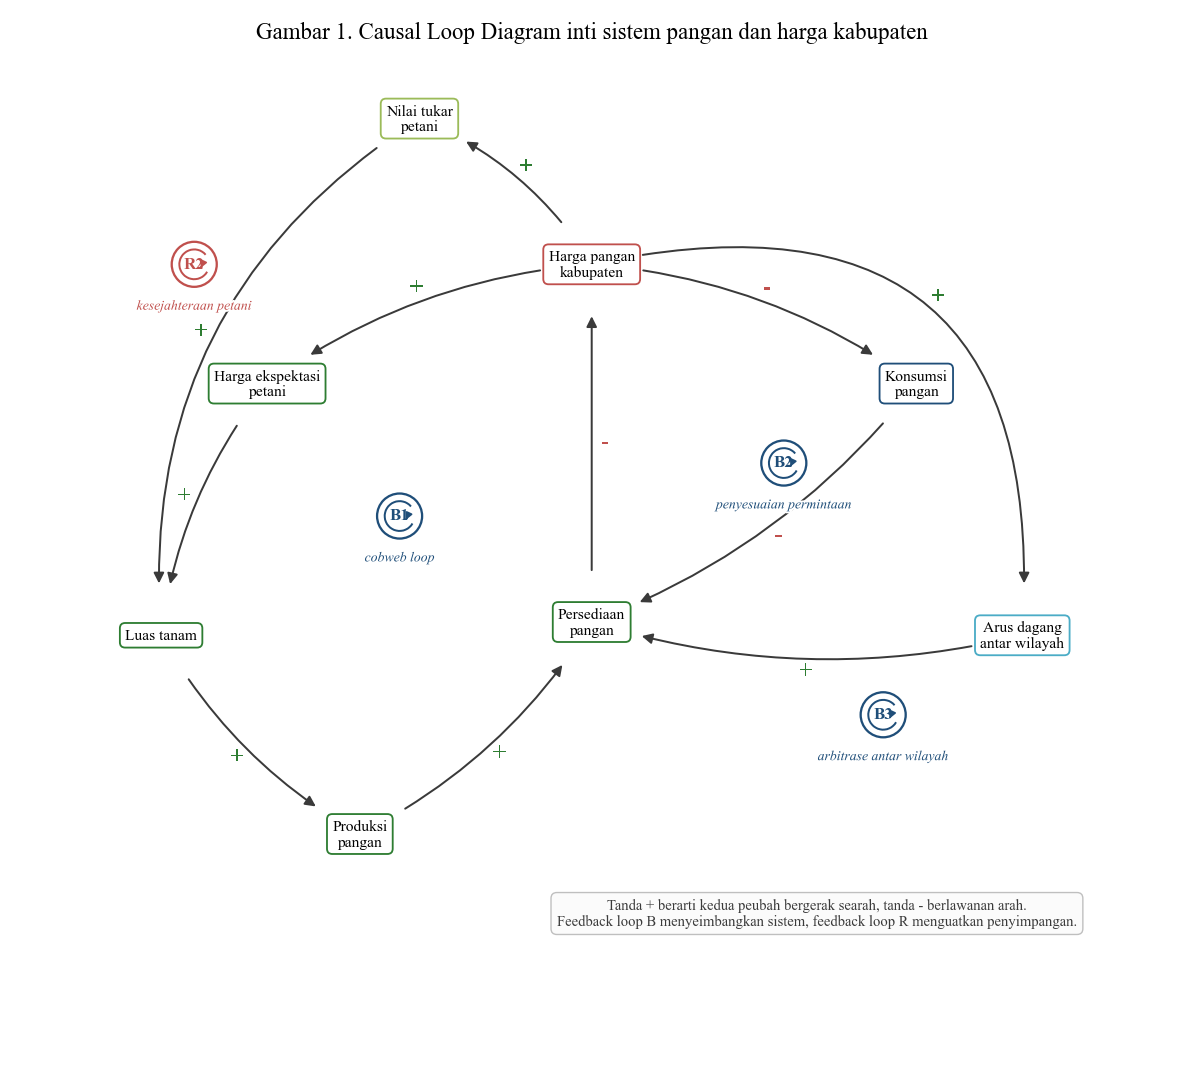

In [4]:
# Sel 3.1 - Causal Loop Diagram inti sistem pangan dan harga

# Satu diagram tunggal untuk delapan feedback loop menghasilkan kerumitan panah yang justru
# menyulitkan pembacaan. Karena itu diagram dipecah menjadi dua, mengikuti praktik lazim
# pada kepustakaan dinamika sistem, dengan harga pangan sebagai node penghubung keduanya.

fig, ax = canvas((-8.6, 8.6), (-7.4, 7.6), ukuran=(13.2, 9.4))

N = {"harga": (0.0, 4.4), "persediaan": (0.0, -1.0), "harapan": (-4.9, 2.6),
     "tanam": (-6.5, -1.2), "produksi": (-3.5, -4.2), "konsumsi": (4.9, 2.6),
     "dagang": (6.5, -1.2), "ntp": (-2.6, 6.6)}
LBL = {"harga": "Harga pangan\nkabupaten", "harapan": "Harga ekspektasi\npetani",
       "tanam": "Luas tanam", "produksi": "Produksi\npangan",
       "persediaan": "Persediaan\npangan", "dagang": "Arus dagang\nantar wilayah",
       "konsumsi": "Konsumsi\npangan", "ntp": "Nilai tukar\npetani"}
WRN = {"harga": PALET[1], "harapan": PALET[8], "tanam": PALET[8], "produksi": PALET[8],
       "persediaan": PALET[8], "dagang": PALET[6], "konsumsi": PALET[0], "ntp": PALET[3]}
for k, xy in N.items():
    node(ax, xy, LBL[k], warna=WRN[k], ukuran=10.2)

for a, b, tanda, r, sisi in [
    ("harga", "harapan", "+", 0.14, 1),
    ("harapan", "tanam", "+", 0.14, 1),
    ("tanam", "produksi", "+", 0.14, 1),
    ("produksi", "persediaan", "+", 0.14, 1),
    ("persediaan", "harga", "-", 0.0, 1),
    ("harga", "konsumsi", "-", -0.14, -1),
    ("konsumsi", "persediaan", "-", -0.14, -1),
    ("harga", "dagang", "+", -0.66, -1),
    ("dagang", "persediaan", "+", -0.14, -1),
    ("harga", "ntp", "+", 0.16, 1),
    ("ntp", "tanam", "+", 0.30, 1),
]:
    panah_kausal(ax, N[a], N[b], tanda, r, sisi=sisi, susut=34)

label_loop(ax, (-2.9, 0.6), "B1", "B", "cobweb loop")
label_loop(ax, (2.9, 1.4), "B2", "B", "penyesuaian permintaan")
label_loop(ax, (4.4, -2.4), "B3", "B", "arbitrase antar wilayah")
label_loop(ax, (-6.0, 4.4), "R2", "R", "kesejahteraan petani")

ax.text(3.4, -5.4, "Tanda + berarti kedua peubah bergerak searah, tanda - berlawanan arah.\n"
        "Feedback loop B menyeimbangkan sistem, feedback loop R menguatkan penyimpangan.",
        fontsize=9.6, ha="center", va="center", color="#3a3a3a",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fbfbfb", edgecolor="0.75", linewidth=0.9))

fig.suptitle("Gambar 1. Causal Loop Diagram inti sistem pangan dan harga kabupaten")
simpan_gambar(fig, "gambar_01_cld_inti_pangan",
              "Causal Loop Diagram inti dengan empat feedback loop sistem pangan dan harga")
plt.show()

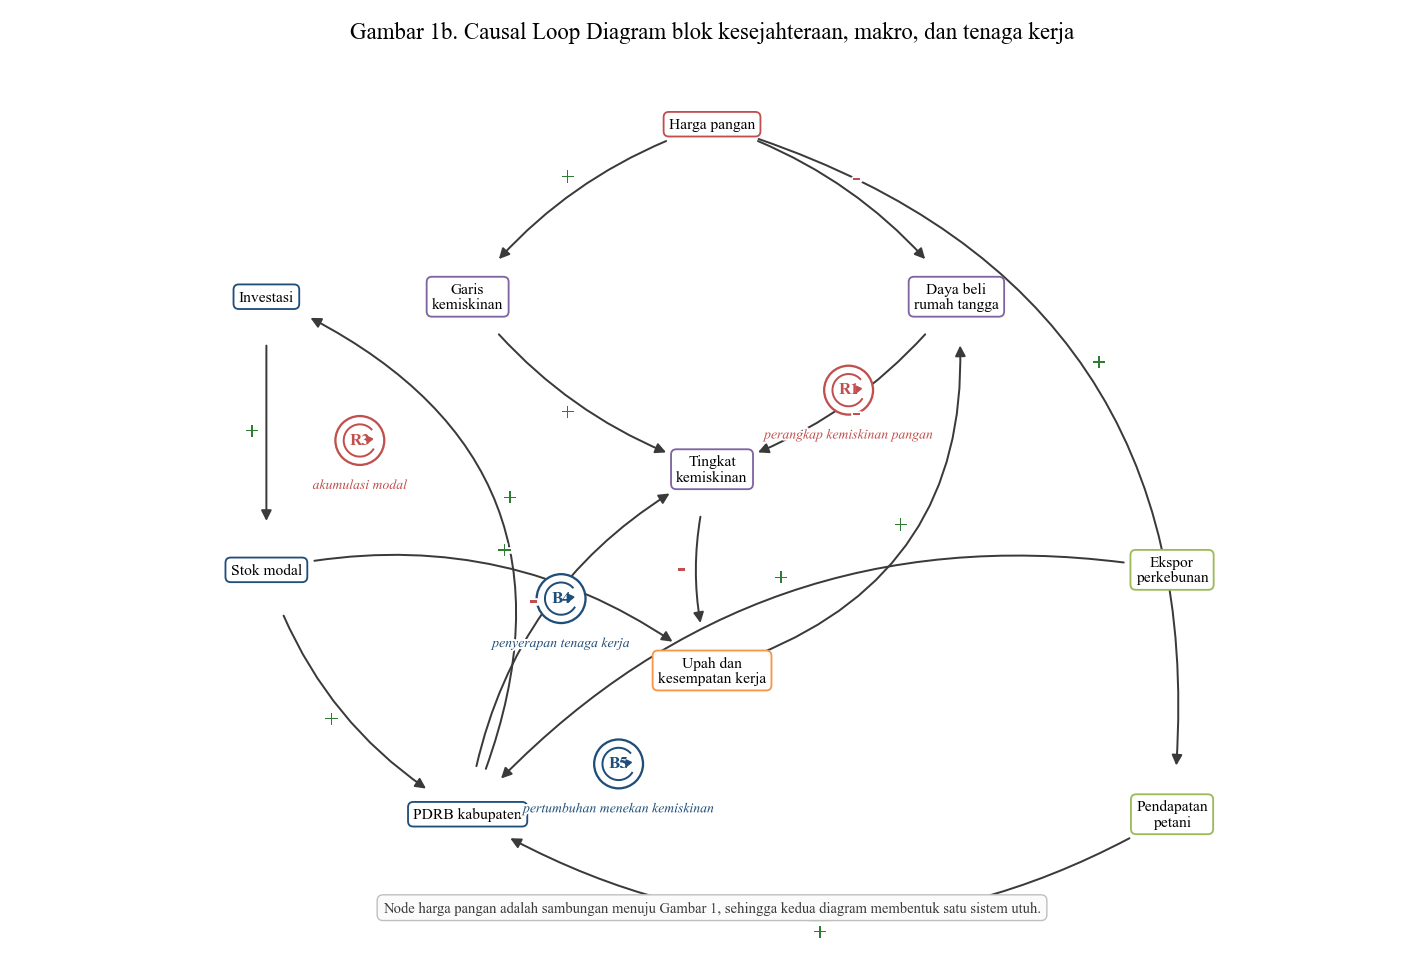

In [5]:
# Sel 3.1b - Causal Loop Diagram blok kesejahteraan, makro, dan tenaga kerja

fig, ax = canvas((-9.6, 9.6), (-6.6, 6.0), ukuran=(13.6, 8.6))

M = {"harga": (0.0, 5.0), "garis": (-3.4, 2.6), "daya_beli": (3.4, 2.6),
     "miskin": (0.0, 0.2), "kerja": (0.0, -2.6), "modal": (-6.2, -1.2),
     "investasi": (-6.2, 2.6), "pdrb": (-3.4, -4.6), "kebun": (6.4, -1.2),
     "tani": (6.4, -4.6)}
LM = {"harga": "Harga pangan", "garis": "Garis\nkemiskinan", "daya_beli": "Daya beli\nrumah tangga",
      "miskin": "Tingkat\nkemiskinan", "kerja": "Upah dan\nkesempatan kerja",
      "modal": "Stok modal", "investasi": "Investasi", "pdrb": "PDRB kabupaten",
      "kebun": "Ekspor\nperkebunan", "tani": "Pendapatan\npetani"}
WM = {"harga": PALET[1], "garis": PALET[4], "daya_beli": PALET[4], "miskin": PALET[4],
      "kerja": PALET[5], "modal": PALET[0], "investasi": PALET[0], "pdrb": PALET[0],
      "kebun": PALET[3], "tani": PALET[3]}
for k, xy in M.items():
    node(ax, xy, LM[k], warna=WM[k], ukuran=10.2)

for a, b, tanda, r, sisi in [
    ("harga", "garis", "+", 0.16, 1), ("harga", "daya_beli", "-", -0.16, -1),
    ("garis", "miskin", "+", 0.16, 1), ("daya_beli", "miskin", "-", -0.16, -1),
    ("miskin", "kerja", "-", 0.16, 1), ("kerja", "daya_beli", "+", 0.42, -1),
    ("investasi", "modal", "+", 0.0, 1), ("modal", "pdrb", "+", 0.20, 1),
    ("pdrb", "investasi", "+", 0.50, 1), ("modal", "kerja", "+", -0.24, -1),
    ("pdrb", "miskin", "-", -0.26, -1), ("harga", "tani", "+", -0.42, -1),
    ("tani", "pdrb", "+", -0.30, -1), ("kebun", "pdrb", "+", 0.28, 1),
]:
    panah_kausal(ax, M[a], M[b], tanda, r, sisi=sisi, susut=32)

label_loop(ax, (1.9, 1.3), "R1", "R", "perangkap kemiskinan pangan")
label_loop(ax, (-4.9, 0.6), "R3", "R", "akumulasi modal")
label_loop(ax, (-2.1, -1.6), "B4", "B", "penyerapan tenaga kerja")
label_loop(ax, (-1.3, -3.9), "B5", "B", "pertumbuhan menekan kemiskinan")

ax.text(0.0, -5.9, "Node harga pangan adalah sambungan menuju Gambar 1, sehingga kedua diagram "
        "membentuk satu sistem utuh.", fontsize=9.6, ha="center", va="center", color="#3a3a3a",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fbfbfb", edgecolor="0.75", linewidth=0.9))

fig.suptitle("Gambar 1b. Causal Loop Diagram blok kesejahteraan, makro, dan tenaga kerja")
simpan_gambar(fig, "gambar_01b_cld_kesejahteraan_makro",
              "Causal Loop Diagram empat feedback loop kesejahteraan, akumulasi modal, dan tenaga kerja")
plt.show()

In [6]:
# Sel 3.2 - Daftar feedback loop dan penentuan polaritasnya

GELUNG = [
    {"kode": "B1", "nama": "Cobweb loop",
     "jalur": "harga pangan naik, harga ekspektasi naik, luas tanam bertambah, produksi naik, "
              "persediaan bertambah, harga pangan turun",
     "n_negatif": 1, "jenis": "Balancing (B)",
     "delay": "panjang, tiga sampai empat bulan tunda tanam ditambah enam bulan penyesuaian luas",
     "makna": "Mekanisme pemulihan harga secara alami. Karena delay-nya panjang, feedback loop ini "
              "cenderung menghasilkan osilasi, bukan peredaman yang mulus."},
    {"kode": "B2", "nama": "Penyesuaian permintaan",
     "jalur": "harga pangan naik, konsumsi turun, persediaan bertambah, harga pangan turun",
     "n_negatif": 3, "jenis": "Balancing (B)", "delay": "sangat pendek, dalam bulan yang sama",
     "makna": "Feedback loop tercepat dalam sistem, tetapi bekerja lewat pengurangan konsumsi, "
              "yang berarti penurunan kesejahteraan, bukan penyelesaian yang diinginkan."},
    {"kode": "B3", "nama": "Arbitrase antar wilayah",
     "jalur": "harga di suatu kabupaten naik di atas acuan, arus dagang masuk, persediaan "
              "bertambah, harga turun kembali",
     "n_negatif": 1, "jenis": "Balancing (B)",
     "delay": "pendek sampai sedang, half-life 0,74 sampai 3,32 bulan menurut komoditas",
     "makna": "Feedback loop yang paling dapat dipengaruhi kebijakan daerah. Kekuatannya diukur "
              "langsung oleh theta pada Notebook 02."},
    {"kode": "R1", "nama": "Perangkap kemiskinan pangan",
     "jalur": "harga pangan naik, garis kemiskinan naik dan daya beli turun, kemiskinan naik, "
              "upah dan kesempatan kerja tertekan, daya beli makin turun",
     "n_negatif": 2, "jenis": "Reinforcing (R)", "delay": "panjang, tahunan",
     "makna": "Feedback loop yang paling berbahaya. Guncangan harga yang berkepanjangan dapat "
              "mengunci rumah tangga pada tingkat kesejahteraan yang lebih rendah secara menetap."},
    {"kode": "R2", "nama": "Kesejahteraan petani",
     "jalur": "harga pangan naik, nilai tukar petani naik, pendapatan petani naik, luas tanam "
              "bertambah, produksi naik",
     "n_negatif": 0, "jenis": "Reinforcing (R)", "delay": "sedang, musiman",
     "makna": "Sisi baik dari kenaikan harga. Feedback loop inilah yang membuat penekanan harga "
              "secara membabi buta merugikan petani."},
    {"kode": "R3", "nama": "Akumulasi modal",
     "jalur": "PDRB naik, investasi naik, stok modal bertambah, PDRB naik lagi",
     "n_negatif": 0, "jenis": "Reinforcing (R)", "delay": "sangat panjang, bertahun tahun",
     "makna": "Mesin pertumbuhan jangka panjang. Bekerja lambat, sehingga tidak dapat "
              "diandalkan untuk meredam guncangan harga jangka pendek."},
    {"kode": "B4", "nama": "Penyerapan tenaga kerja",
     "jalur": "stok modal bertambah, penyerapan tenaga kerja naik, upah dan kesempatan kerja "
              "naik, daya beli naik, konsumsi naik, persediaan berkurang, harga naik",
     "n_negatif": 1, "jenis": "Balancing (B)", "delay": "panjang",
     "makna": "Batas alami pertumbuhan. Pertumbuhan menaikkan permintaan pangan, sehingga "
              "sebagian manfaatnya terserap kembali menjadi tekanan harga."},
    {"kode": "B5", "nama": "Pertumbuhan menekan kemiskinan",
     "jalur": "PDRB naik, kemiskinan turun, upah dan kesempatan kerja membaik, daya beli naik",
     "n_negatif": 1, "jenis": "Balancing (B)", "delay": "panjang",
     "makna": "Jalur pertumbuhan menuju pengurangan kemiskinan. Elastisitasnya terestimasi "
              "pada Notebook 02 tetapi belum presisi."},
]
TABEL_LOOP = pd.DataFrame(GELUNG)
TABEL_LOOP["polaritas_terhitung"] = np.where(TABEL_LOOP.n_negatif % 2 == 0,
                                               "Reinforcing (R)", "Balancing (B)")
TABEL_LOOP["konsisten"] = TABEL_LOOP.jenis == TABEL_LOOP.polaritas_terhitung
simpan(TABEL_LOOP, "tabel/daftar_feedback_loop.csv")

print("DAFTAR GELUNG UMPAN BALIK")
print("Kaidah penentuan polaritas: feedback loop dengan jumlah tanda negatif GENAP bersifat menguat,")
print("dengan jumlah GANJIL bersifat menyeimbangkan.")
print()
print(TABEL_LOOP[["kode", "nama", "n_negatif", "polaritas_terhitung", "konsisten", "delay"]]
      .to_string(index=False))
print()
print("Seluruh polaritas konsisten dengan kaidah hitung:", bool(TABEL_LOOP.konsisten.all()))
print("Reinforcing loop (R)  :", int((TABEL_LOOP.polaritas_terhitung == "Reinforcing (R)").sum()))
print("Balancing loop (B):", int((TABEL_LOOP.polaritas_terhitung == "Balancing (B)").sum()))
print()
for r in GELUNG:
    print(r["kode"], "-", r["nama"])
    print("   jalur :", r["jalur"])
    print("   makna :", r["makna"])
    print()

DAFTAR GELUNG UMPAN BALIK
Kaidah penentuan polaritas: feedback loop dengan jumlah tanda negatif GENAP bersifat menguat,
dengan jumlah GANJIL bersifat menyeimbangkan.

kode                           nama  n_negatif polaritas_terhitung  konsisten                                                                             delay
  B1                    Cobweb loop          1       Balancing (B)       True panjang, tiga sampai empat bulan tunda tanam ditambah enam bulan penyesuaian luas
  B2         Penyesuaian permintaan          3       Balancing (B)       True                                              sangat pendek, dalam bulan yang sama
  B3        Arbitrase antar wilayah          1       Balancing (B)       True          pendek sampai sedang, half-life 0,74 sampai 3,32 bulan menurut komoditas
  R1    Perangkap kemiskinan pangan          2     Reinforcing (R)       True                                                                  panjang, tahunan
  R2           Kesejahteraan peta

---
## Bagian 4. Stock and Flow Diagram

Causal Loop Diagram bagus untuk melihat feedback loop, tetapi tidak membedakan mana yang terakumulasi dan mana
yang tidak. Perbedaan itu menentukan segalanya dalam simulasi. Stock and Flow Diagram menyatakannya
secara tegas.

Dua diagram disajikan. Yang pertama menampilkan blok pangan dan harga secara rinci, sebab di situlah
seluruh material delay dan rationing bekerja. Yang kedua menampilkan sambungan antar tujuh blok pada
tingkat yang lebih ringkas, agar keterkaitan lintas sektor terlihat utuh.

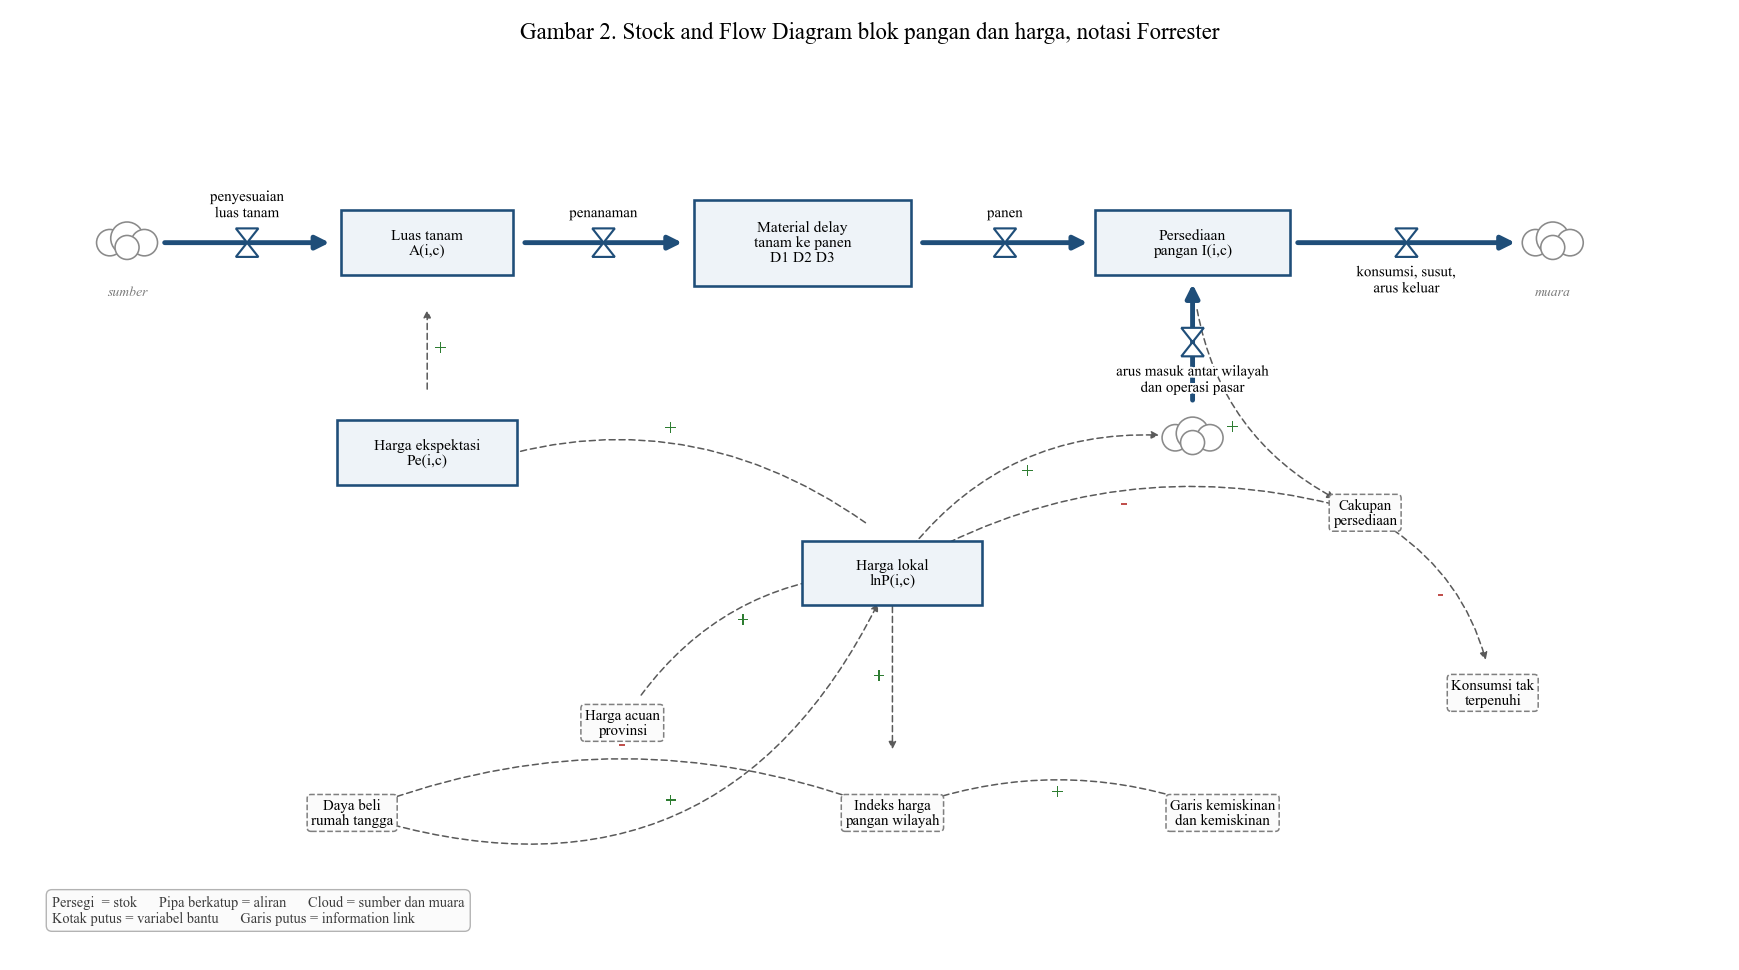

In [7]:
# Sel 4.1 - Stock and Flow Diagram blok pangan dan harga

fig, ax = canvas((-11.0, 11.6), (-6.4, 5.4), ukuran=(15.5, 8.6))

cloud(ax, (-9.6, 3.0))
stok(ax, (-5.6, 3.0), "Luas tanam\nA(i,c)", w=2.3)
stok(ax, (-0.6, 3.0), "Material delay\ntanam ke panen\nD1 D2 D3", w=2.9, h=1.15)
stok(ax, (4.6, 3.0), "Persediaan\npangan I(i,c)", w=2.6)
cloud(ax, (9.4, 3.0))
aliran(ax, (-9.2, 3.0), (-6.8, 3.0), "penyesuaian\nluas tanam")
aliran(ax, (-4.4, 3.0), (-2.1, 3.0), "penanaman")
aliran(ax, (0.9, 3.0), (3.3, 3.0), "panen")
aliran(ax, (5.9, 3.0), (9.0, 3.0), "konsumsi, susut,\narus keluar", atas=False)

cloud(ax, (4.6, 0.4))
aliran(ax, (4.6, 0.8), (4.6, 2.55), "arus masuk antar wilayah\ndan operasi pasar", atas=False)

stok(ax, (-5.6, 0.2), "Harga ekspektasi\nPe(i,c)", w=2.4)
stok(ax, (0.6, -1.4), "Harga lokal\nlnP(i,c)", w=2.4)
bantu(ax, (6.9, -0.6), "Cakupan\npersediaan")
bantu(ax, (8.6, -3.0), "Konsumsi tak\nterpenuhi")
bantu(ax, (-3.0, -3.4), "Harga acuan\nprovinsi")
bantu(ax, (0.6, -4.6), "Indeks harga\npangan wilayah")
bantu(ax, (5.0, -4.6), "Garis kemiskinan\ndan kemiskinan")
bantu(ax, (-6.6, -4.6), "Daya beli\nrumah tangga")

tautan(ax, (0.6, -1.0), (-5.6, -0.2), 0.30, "+")
tautan(ax, (-5.6, 0.6), (-5.6, 2.55), 0.0, "+")
tautan(ax, (4.6, 2.55), (6.9, -0.6), 0.30, "+")
tautan(ax, (6.9, -0.6), (0.6, -1.4), 0.22, "-", sisi=-1)
tautan(ax, (6.9, -0.6), (8.6, -3.0), -0.25, "-")
tautan(ax, (-3.0, -3.4), (0.6, -1.4), -0.28, "+")
tautan(ax, (0.6, -1.4), (0.6, -4.2), 0.0, "+")
tautan(ax, (0.6, -4.6), (5.0, -4.6), -0.20, "+")
tautan(ax, (0.6, -4.6), (-6.6, -4.6), 0.20, "-")
tautan(ax, (-6.6, -4.6), (0.6, -1.4), 0.45, "+", sisi=-1)
tautan(ax, (0.6, -1.4), (4.6, 0.4), -0.30, "+")

ax.text(-9.6, 2.3, "sumber", fontsize=9, color="#7a7a7a", ha="center", style="italic")
ax.text(9.4, 2.3, "muara", fontsize=9, color="#7a7a7a", ha="center", style="italic")
ket = ("Persegi  = stok      Pipa berkatup = aliran      Cloud = sumber dan muara\n"
       "Kotak putus = variabel bantu      Garis putus = information link")
ax.text(-10.6, -5.9, ket, fontsize=9.4, color="#3a3a3a", ha="left", va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fbfbfb", edgecolor="0.7", linewidth=0.9))

fig.suptitle("Gambar 2. Stock and Flow Diagram blok pangan dan harga, notasi Forrester")
simpan_gambar(fig, "gambar_02_stock_flow_pangan",
              "Stock and Flow Diagram blok pangan dan harga beserta tautan ke blok kesejahteraan")
plt.show()

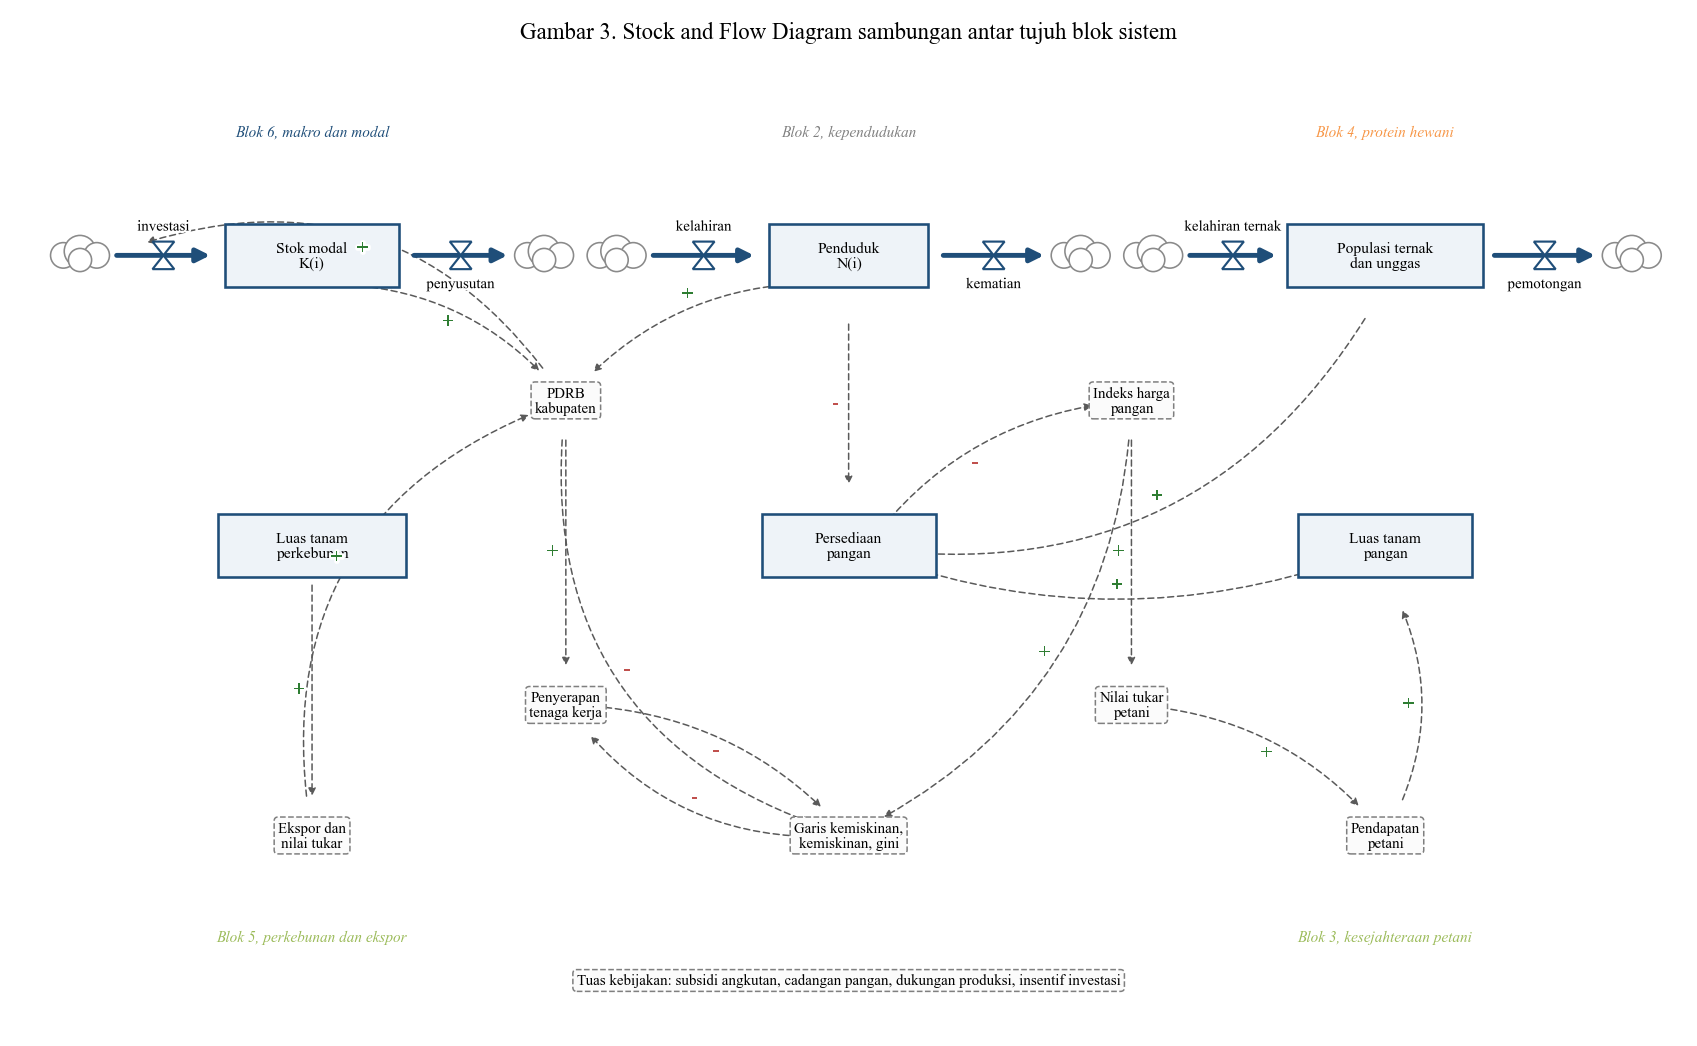

In [8]:
# Sel 4.2 - Stock and Flow Diagram sambungan antar blok

fig, ax = canvas((-11.4, 11.4), (-7.0, 6.4), ukuran=(15.5, 9.2))

stok(ax, (-7.4, 3.6), "Stok modal\nK(i)", w=2.4)
stok(ax, (0.0, 3.6), "Penduduk\nN(i)", w=2.2)
stok(ax, (7.4, 3.6), "Populasi ternak\ndan unggas", w=2.7)
stok(ax, (-7.4, -0.4), "Luas tanam\nperkebunan", w=2.6)
stok(ax, (0.0, -0.4), "Persediaan\npangan", w=2.4)
stok(ax, (7.4, -0.4), "Luas tanam\npangan", w=2.4)

cloud(ax, (-10.6, 3.6)); aliran(ax, (-10.2, 3.6), (-8.7, 3.6), "investasi")
cloud(ax, (-4.2, 3.6)); aliran(ax, (-6.1, 3.6), (-4.6, 3.6), "penyusutan", atas=False)
cloud(ax, (-3.2, 3.6)); aliran(ax, (-2.8, 3.6), (-1.2, 3.6), "kelahiran")
cloud(ax, (3.2, 3.6)); aliran(ax, (1.2, 3.6), (2.8, 3.6), "kematian", atas=False)
cloud(ax, (10.8, 3.6)); aliran(ax, (8.8, 3.6), (10.4, 3.6), "pemotongan", atas=False)
cloud(ax, (4.2, 3.6)); aliran(ax, (4.6, 3.6), (6.0, 3.6), "kelahiran ternak")

bantu(ax, (-3.9, 1.6), "PDRB\nkabupaten")
bantu(ax, (3.9, 1.6), "Indeks harga\npangan")
bantu(ax, (-3.9, -2.6), "Penyerapan\ntenaga kerja")
bantu(ax, (3.9, -2.6), "Nilai tukar\npetani")
bantu(ax, (-7.4, -4.4), "Ekspor dan\nnilai tukar")
bantu(ax, (0.0, -4.4), "Garis kemiskinan,\nkemiskinan, gini")
bantu(ax, (7.4, -4.4), "Pendapatan\npetani")
bantu(ax, (0.0, -6.4), "Tuas kebijakan: subsidi angkutan, cadangan pangan, dukungan produksi, insentif investasi")

for p1, p2, r, tanda, sisi in [
    ((-7.4, 3.2), (-3.9, 1.6), -0.25, "+", 1), ((0.0, 3.2), (-3.9, 1.6), 0.25, "+", 1),
    ((-3.9, 1.6), (-10.2, 3.6), 0.40, "+", -1), ((-3.9, 1.6), (-3.9, -2.6), 0.0, "+", 1),
    ((-3.9, -2.6), (0.0, -4.4), -0.22, "-", 1), ((-3.9, 1.6), (0.0, -4.4), 0.42, "-", -1),
    ((0.0, -0.8), (3.9, 1.6), -0.25, "-", 1), ((3.9, 1.6), (0.0, -4.4), -0.30, "+", 1),
    ((3.9, 1.6), (3.9, -2.6), 0.0, "+", 1), ((3.9, -2.6), (7.4, -4.4), -0.22, "+", 1),
    ((7.4, -4.4), (7.4, -0.8), 0.28, "+", -1), ((7.4, -0.4), (0.0, -0.4), -0.20, "+", 1),
    ((7.4, 3.2), (0.0, -0.4), -0.35, "+", 1), ((-7.4, -0.4), (-7.4, -4.4), 0.0, "+", 1),
    ((-7.4, -4.4), (-3.9, 1.6), -0.42, "+", -1), ((0.0, 3.2), (0.0, -0.1), 0.0, "-", 1),
    ((0.0, -4.4), (-3.9, -2.6), -0.28, "-", 1),
]:
    tautan(ax, p1, p2, r, tanda, sisi=sisi, susut=26)

for xy, t, w in [((-7.4, 5.3), "Blok 6, makro dan modal", PALET[0]),
                 ((0.0, 5.3), "Blok 2, kependudukan", PALET[7]),
                 ((7.4, 5.3), "Blok 4, protein hewani", PALET[5]),
                 ((-7.4, -5.8), "Blok 5, perkebunan dan ekspor", PALET[3]),
                 ((7.4, -5.8), "Blok 3, kesejahteraan petani", PALET[3])]:
    ax.text(xy[0], xy[1], t, fontsize=10, color=w, style="italic", ha="center", va="center")

fig.suptitle("Gambar 3. Stock and Flow Diagram sambungan antar tujuh blok sistem")
simpan_gambar(fig, "gambar_03_stock_flow_antar_blok",
              "Sambungan antar blok pangan, kesejahteraan, makro, tenaga kerja, dan perkebunan")
plt.show()

---
## Bagian 5. Estimasi parameter blok baru

Blok blok yang ditambahkan memerlukan parameternya sendiri, dan parameter itu diestimasi di sini dari
panel tahunan kabupaten, bukan diasumsikan. Empat hubungan diestimasi.

**Fungsi produksi agregat.** PDRB kabupaten dijelaskan oleh stok modal dan tenaga kerja dalam bentuk
Cobb Douglas, diestimasi pada logaritma dengan efek tetap wilayah lewat pembedaan pertama:

$$\Delta \ln Y_{i,t} = \alpha \,\Delta \ln K_{i,t} + \beta \,\Delta \ln L_{i,t} + \delta_t + \varepsilon_{i,t}$$

**Penyerapan tenaga kerja.** Jumlah bekerja terhadap stok modal dan PDRB.

**Ketimpangan.** Rasio gini terhadap PDRB per kapita dan harga pangan.

**Perkebunan dan ekspor.** Nilai ekspor provinsi terhadap produksi perkebunan dan kurs, diestimasi pada
seri bulanan provinsi karena ekspor hanya tersedia pada tingkat itu.

Seperti pada notebook 02, tiap estimasi disertai galat baku berkelompok dan penilaian presisi. Yang
tidak presisi tidak dipakai sebagai nilai titik.

In [9]:
# Sel 5.1 - Penyiapan panel untuk estimasi blok baru

W = KAB.copy().sort_values(["kode_wilayah", "tahun"])

# Tingkat partisipasi angkatan kerja ternyata hanya tersedia pada satu tahun, yaitu 2025,
# sehingga jumlah bekerja tidak dapat dihitung penuh untuk seluruh tahun. Yang dipakai
# adalah proksi: penduduk dikalikan satu dikurangi tingkat pengangguran terbuka, dengan
# tingkat partisipasi ditetapkan tetap pada nilai 2025 tiap wilayah. Proksi ini menangkap
# dua sumber gerak yang benar, yaitu pertambahan penduduk dan perubahan pengangguran,
# tetapi mengabaikan perubahan partisipasi. Keterbatasan itu dicatat dan diikutkan pada
# bagian keterbatasan naskah.
tpak_2025 = W[W.tahun == 2025].set_index("kode_wilayah")["TPAK_persen"]
W["TPAK_dipakai"] = W["kode_wilayah"].map(tpak_2025)
W["TPAK_dipakai"] = W["TPAK_dipakai"].fillna(float(tpak_2025.median()))
W["Bekerja_jiwa"] = (W["Penduduk_Total_jiwa"] * W["TPAK_dipakai"] / 100.0
                     * (1 - W["TPT_persen"] / 100.0))
print("Tingkat partisipasi angkatan kerja tersedia pada",
      int(KAB.groupby("tahun")["TPAK_persen"].apply(lambda x: x.notna().any()).sum()),
      "dari", KAB.tahun.nunique(), "tahun, sehingga jumlah bekerja memakai proksi.")
peta_log = {"PDRB_miliarRp": "l_y", "Stok_Modal_jutaRp": "l_k", "Bekerja_jiwa": "l_l",
            "Penduduk_Total_jiwa": "l_n", "Investasi_PMA_PMDN_jutaRp": "l_inv",
            "Gini_Ratio": "l_gini", "TPT_persen": "l_tpt", "TPAK_persen": "l_tpak",
            "Kemiskinan_Persentase": "l_p0", "GarisKemiskinan_Rp_kapita_bulan": "l_gk",
            "Pengeluaran_Total_Rp": "l_peng"}
for a, b in peta_log.items():
    if a in W.columns:
        W[b] = np.log(W[a].where(W[a] > 0))
W["l_ypc"] = W.l_y + np.log(1000) - W.l_n
W["l_kpc"] = W.l_k - W.l_n
for v in [v for v in peta_log.values() if v in W.columns] + ["l_ypc", "l_kpc"]:
    W["d_" + v] = W.groupby("kode_wilayah")[v].diff()

# Indeks harga pangan kabupaten dari notebook 02, untuk blok ketimpangan
IHP_KAB = pd.read_csv(DIR_NB02 / "tabel" / "indeks_harga_pangan_kabupaten.csv",
                      dtype={"kode_wilayah": str})
W = W.merge(IHP_KAB[["kode_wilayah", "tahun", "l_ipangan"]], on=["kode_wilayah", "tahun"], how="left")
W["d_l_ipangan"] = W.groupby("kode_wilayah")["l_ipangan"].diff()

print("PANEL UNTUK ESTIMASI BLOK BARU")
print("Baris panel:", len(W), "| wilayah:", W.kode_wilayah.nunique(),
      "| tahun:", int(W.tahun.min()), "sampai", int(W.tahun.max()))
print()
print("Keterisian variabel kunci pada bentuk pembedaan pertama:")
for v in ["d_l_y", "d_l_k", "d_l_l", "d_l_gini", "d_l_tpt", "d_l_ipangan"]:
    if v in W.columns:
        print("  ", v.ljust(14), int(W[v].notna().sum()), "amatan")

Tingkat partisipasi angkatan kerja tersedia pada 1 dari 13 tahun, sehingga jumlah bekerja memakai proksi.
PANEL UNTUK ESTIMASI BLOK BARU
Baris panel: 429 | wilayah: 33 | tahun: 2014 sampai 2026

Keterisian variabel kunci pada bentuk pembedaan pertama:
   d_l_y          363 amatan
   d_l_k          396 amatan
   d_l_l          264 amatan
   d_l_gini       363 amatan
   d_l_tpt        297 amatan
   d_l_ipangan    110 amatan


In [10]:
# Sel 5.2 - Estimasi keempat hubungan

PARAM_BARU = []
def estimasi(y, X, label, peran, data=W, fe_tahun=True):
    s = data.dropna(subset=[y] + X).copy()
    if len(s) < 25:
        print(label, "-> observasi tidak mencukupi:", len(s)); return None
    bagian = [s[X].reset_index(drop=True)]
    if fe_tahun:
        bagian.append(pd.get_dummies(s.tahun, prefix="th", drop_first=True)
                      .astype(float).reset_index(drop=True))
    else:
        bagian.append(pd.Series(s.tahun.values - s.tahun.min(), name="tren")
                      .astype(float).reset_index(drop=True))
    XX = sm.add_constant(pd.concat(bagian, axis=1))
    m = sm.OLS(s[y].reset_index(drop=True), XX).fit(
        cov_type="cluster", cov_kwds={"groups": s.kode_wilayah.reset_index(drop=True)})
    print(label)
    print("   n =", int(m.nobs), "| wilayah =", s.kode_wilayah.nunique(), "| R2 =", round(m.rsquared, 3))
    for v in X:
        b, se, p = float(m.params[v]), float(m.bse[v]), float(m.pvalues[v])
        rasio = abs(b) / se if se > 0 else 0
        presisi = "tinggi" if rasio >= 2.58 else ("sedang" if rasio >= 1.96 else "rendah")
        print("     " + v.ljust(14), format(b, "+.4f"), " se", format(se, ".4f"),
              " p", format(p, ".4f"), " presisi", presisi)
        PARAM_BARU.append({"blok": peran, "parameter": label + " | " + v, "nilai": b,
                           "galat_baku": se, "nilai_p": p, "n_amatan": int(m.nobs),
                           "presisi": presisi,
                           "batas_bawah_95": b - 1.96 * se, "batas_atas_95": b + 1.96 * se})
    return m

print("BLOK 6. FUNGSI PRODUKSI AGREGAT")
print("=" * 72)
m_y = estimasi("d_l_y", ["d_l_k", "d_l_l"], "PDRB thd modal dan tenaga kerja", "Blok 6 makro")
print()
print("BLOK 7. PENYERAPAN TENAGA KERJA")
print("=" * 72)
m_l = estimasi("d_l_l", ["d_l_k", "d_l_n"], "Tenaga kerja thd modal dan penduduk", "Blok 7 tenaga kerja")
print()
m_tpt = estimasi("d_l_tpt", ["d_l_ypc"], "Pengangguran thd PDRB per kapita", "Blok 7 tenaga kerja")
print()
print("BLOK 3. KETIMPANGAN")
print("=" * 72)
m_g = estimasi("d_l_gini", ["d_l_ypc", "d_l_ipangan"], "Gini thd PDRB per kapita dan harga pangan",
               "Blok 3 kesejahteraan", fe_tahun=False)
print()
print("BLOK 6. INVESTASI")
print("=" * 72)
m_inv = estimasi("d_l_inv", ["d_l_y"], "Investasi thd PDRB", "Blok 6 makro")

TABEL_PARAM_BARU = pd.DataFrame(PARAM_BARU)
simpan(TABEL_PARAM_BARU, "tabel/parameter_blok_baru.csv")
print()
print("RANGKUMAN PARAMETER BLOK BARU")
print(TABEL_PARAM_BARU[["blok", "parameter", "nilai", "galat_baku", "nilai_p", "presisi"]]
      .round(4).to_string(index=False))
print()
print("Sebaran presisi:", dict(TABEL_PARAM_BARU.presisi.value_counts()))

BLOK 6. FUNGSI PRODUKSI AGREGAT
PDRB thd modal dan tenaga kerja
   n = 264 | wilayah = 33 | R2 = 0.872
     d_l_k          -0.0002  se 0.0006  p 0.7611  presisi rendah
     d_l_l          -0.0040  se 0.0163  p 0.8048  presisi rendah

BLOK 7. PENYERAPAN TENAGA KERJA
Tenaga kerja thd modal dan penduduk
   n = 264 | wilayah = 33 | R2 = 0.902
     d_l_k          +0.0007  se 0.0006  p 0.2604  presisi rendah
     d_l_n          +1.0189  se 0.0139  p 0.0000  presisi tinggi

Pengangguran thd PDRB per kapita
   n = 264 | wilayah = 33 | R2 = 0.184
     d_l_ypc        +1.5522  se 0.6490  p 0.0168  presisi sedang

BLOK 3. KETIMPANGAN
Gini thd PDRB per kapita dan harga pangan
   n = 110 | wilayah = 22 | R2 = 0.005
     d_l_ypc        +0.1306  se 0.3505  p 0.7094  presisi rendah
     d_l_ipangan    +0.0074  se 0.1457  p 0.9596  presisi rendah

BLOK 6. INVESTASI
Investasi thd PDRB
   n = 286 | wilayah = 33 | R2 = 0.04
     d_l_y          +4.6812  se 14.8841  p 0.7531  presisi rendah

RANGKUMAN PARAME

In [11]:
# Sel 5.3 - Blok perkebunan dan ekspor pada seri bulanan provinsi

pb = PANEL_BULANAN.copy()
pb["t"] = pd.PeriodIndex(pb.periode, freq="M")
eks = pb.dropna(subset=["ekspor_nilai_USD", "kurs_Rp_per_USD"]).copy()
eks["l_eks"] = np.log(eks.ekspor_nilai_USD.where(eks.ekspor_nilai_USD > 0))
eks["l_kurs"] = np.log(eks.kurs_Rp_per_USD)
eks["l_imp"] = np.log(eks.impor_nilai_USD.where(eks.impor_nilai_USD > 0))
for v in ["l_eks", "l_kurs", "l_imp"]:
    eks["d_" + v] = eks[v].diff()
eks["d_l_kurs_1"] = eks["d_l_kurs"].shift(1)

s = eks.dropna(subset=["d_l_eks", "d_l_kurs", "d_l_kurs_1"])
m_eks = sm.OLS(s.d_l_eks, sm.add_constant(s[["d_l_kurs", "d_l_kurs_1"]])).fit(
    cov_type="HAC", cov_kwds={"maxlags": 4})
print("BLOK 5. EKSPOR PROVINSI TERHADAP KURS")
print("  n =", int(m_eks.nobs), "| R2 =", round(m_eks.rsquared, 3))
for v in ["d_l_kurs", "d_l_kurs_1"]:
    b, se, p = float(m_eks.params[v]), float(m_eks.bse[v]), float(m_eks.pvalues[v])
    rasio = abs(b) / se if se > 0 else 0
    presisi = "tinggi" if rasio >= 2.58 else ("sedang" if rasio >= 1.96 else "rendah")
    print("     " + v.ljust(12), format(b, "+.4f"), " se", format(se, ".4f"),
          " p", format(p, ".4f"), " presisi", presisi)
    PARAM_BARU.append({"blok": "Blok 5 perkebunan dan ekspor",
                       "parameter": "Ekspor thd kurs | " + v, "nilai": b, "galat_baku": se,
                       "nilai_p": p, "n_amatan": int(m_eks.nobs), "presisi": presisi,
                       "batas_bawah_95": b - 1.96 * se, "batas_atas_95": b + 1.96 * se})
print()
# Pangsa perkebunan pada perekonomian kabupaten, dipakai sebagai bobot penyaluran ekspor
kol_kebun = [c for c in KAB.columns if c.startswith("Perkebunan_") and c.endswith("_ton")]
thn_kebun = int(KAB.dropna(subset=kol_kebun, how="all").tahun.max())
kebun = KAB[KAB.tahun == thn_kebun].set_index("kode_wilayah")[kol_kebun].reindex(KODE)
PANGSA_KEBUN = np.nan_to_num(kebun.sum(axis=1).values)
PANGSA_KEBUN = PANGSA_KEBUN / max(PANGSA_KEBUN.sum(), 1e-9)
print("Produksi perkebunan tahun", thn_kebun, ":", format(int(np.nan_to_num(kebun.values).sum()), ","),
      "ton pada", int((PANGSA_KEBUN > 0).sum()), "wilayah yang melapor")
atas = np.argsort(-PANGSA_KEBUN)[:6]
print("Enam wilayah dengan pangsa perkebunan terbesar:")
for i in atas:
    if PANGSA_KEBUN[i] > 0:
        print("  ", NAMA[KODE[i]].ljust(22), format(100 * PANGSA_KEBUN[i], "6.2f"), "persen")
print()
print("Keterbatasan yang perlu dinyatakan. Data perkebunan hanya terisi",
      round(float(KAB[kol_kebun].notna().mean().mean() * 100), 1), "persen,")
print("sehingga blok ini bekerja pada tingkat provinsi dan disalurkan ke kabupaten memakai")
print("pangsa produksi tahun terakhir yang tersedia, bukan diestimasi per kabupaten.")

TABEL_PARAM_BARU = pd.DataFrame(PARAM_BARU)
simpan(TABEL_PARAM_BARU, "tabel/parameter_blok_baru.csv")

BLOK 5. EKSPOR PROVINSI TERHADAP KURS
  n = 76 | R2 = 0.015
     d_l_kurs     -0.1459  se 0.7054  p 0.8361  presisi rendah
     d_l_kurs_1   -0.8922  se 0.7616  p 0.2414  presisi rendah

Produksi perkebunan tahun 2024 : 8,789 ton pada 27 wilayah yang melapor
Enam wilayah dengan pangsa perkebunan terbesar:
   Asahan                  19.19 persen
   Labuhanbatu Utara       15.92 persen
   Langkat                  9.44 persen
   Labuhanbatu Selatan      9.12 persen
   Simalungun               8.53 persen
   Padang Lawas             7.11 persen

Keterbatasan yang perlu dinyatakan. Data perkebunan hanya terisi 15.4 persen,
sehingga blok ini bekerja pada tingkat provinsi dan disalurkan ke kabupaten memakai
pangsa produksi tahun terakhir yang tersedia, bukan diestimasi per kabupaten.


PosixPath('/Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB04/tabel/parameter_blok_baru.csv')

---
## Bagian 6. Mesin simulasi sistem penuh

Model kini berjalan pada dua skala waktu sekaligus. Blok pangan dan harga tetap bulanan, sebab harga
memang bergerak bulanan. Blok makro, tenaga kerja, dan kesejahteraan berjalan tahunan, sebab stok modal
dan penduduk memang bergerak tahunan dan datanya pun tahunan.

Keduanya disambungkan pada tiap pergantian tahun. Blok bulanan menyerahkan indeks harga pangan rata rata
setahun ke blok tahunan; blok tahunan menyerahkan penduduk, daya beli, dan pendapatan petani ke blok
bulanan untuk tahun berikutnya. Cara ini menjaga agar tiap blok bekerja pada skala waktu yang wajar,
sekaligus membuat umpan baliknya tetap tertutup.

Tujuh blok yang berjalan:

1. Pangan dan harga, bulanan, enam komoditas kali 33 wilayah
2. Kependudukan, tahunan
3. Kesejahteraan, tahunan, mencakup garis kemiskinan, kemiskinan, dan gini
4. Protein hewani, tahunan, populasi ternak dan unggas
5. Perkebunan dan ekspor, tahunan
6. Makro, tahunan, stok modal dan PDRB
7. Tenaga kerja, tahunan

In [12]:
# Sel 6.1 - Pemuatan kondisi awal seluruh blok

SP = SPEK
THETA = np.array(SP["theta"]); BETA = np.array(SP["beta"]); PSI = np.array(SP["psi"])
MUSIM = np.array(SP["musim_panen"]); KONS_PC = np.array(SP["konsumsi_per_kapita_ton_tahun"])
HARGA_AWAL = np.array(SP["harga_awal"]); PRODUKSI = np.array(SP["produksi_ton"])
LUAS = np.array(SP["luas_ha"]); POP0 = np.array(SP["penduduk"])
OMEGA = np.array(SP["omega_indeks_model"]); GK0 = np.array(SP["garis_kemiskinan_awal"])
P00 = np.array(SP["kemiskinan_awal_persen"]); LN_ACUAN = np.array(SP["ln_acuan_historis"])
LN_ACUAN_DEPAN = np.array(SP["ln_acuan_depan"])
PARB = {k: (np.array(v) if isinstance(v, list) else v)
        for k, v in SP["parameter_perilaku"].items()}
E_GK, E_GK_LO, E_GK_HI = SP["elastisitas"]["gk_thd_harga_pangan"]
E_P0, E_P0_LO, E_P0_HI = SP["elastisitas"]["kemiskinan_thd_gk"]
ETA, ETA_LO, ETA_HI = SP["elastisitas"]["respons_penawaran"]
NT = len(LN_ACUAN); H_DEPAN = len(LN_ACUAN_DEPAN)

# Aturan pemakaian parameter. Sebuah estimasi hanya dipakai sebagai nilai titik bila
# DUA syarat terpenuhi sekaligus: presisinya sedang atau tinggi, DAN nilainya berada di
# dalam rentang yang sah secara teori. Rentang sah bukan selera, melainkan syarat agar
# sistem tetap stabil dan tafsirannya masuk akal. Elastisitas investasi terhadap PDRB di
# atas satu, misalnya, membuat feedback loop akumulasi modal meledak tanpa batas. Estimasi yang
# gagal salah satu syarat digantikan nilai acuan yang disebutkan sumbernya, dan seluruh
# keputusan penggantian dicatat pada tabel agar terlihat.
SELEKSI = []
def pakai(nama_mengandung, acuan, rentang, alasan_acuan):
    r = TABEL_PARAM_BARU[TABEL_PARAM_BARU.parameter.str.contains(nama_mengandung, regex=False)]
    if len(r) == 0:
        nilai, se, pres, sumber = acuan, np.nan, "tidak terestimasi", "Nilai acuan"
    else:
        nilai = float(r.nilai.iloc[0]); se = float(r.galat_baku.iloc[0])
        pres = str(r.presisi.iloc[0])
        sah_presisi = pres in ("tinggi", "sedang")
        sah_rentang = rentang[0] <= nilai <= rentang[1]
        if sah_presisi and sah_rentang:
            sumber = "Estimasi Notebook 04"
        else:
            sumber = ("Nilai acuan, estimasi tidak presisi" if not sah_presisi
                      else "Nilai acuan, estimasi di luar rentang sah")
            nilai = acuan
    SELEKSI.append({"parameter": nama_mengandung, "nilai_dipakai": nilai,
                    "nilai_estimasi": float(r.nilai.iloc[0]) if len(r) else np.nan,
                    "presisi_estimasi": pres if len(r) else "tidak terestimasi",
                    "rentang_sah": str(rentang), "sumber": sumber,
                    "alasan_nilai_acuan": alasan_acuan})
    return nilai

ALPHA_K = pakai("PDRB thd modal dan tenaga kerja | d_l_k", 0.35, (0.05, 0.75),
                "Pangsa modal pada fungsi Cobb Douglas Indonesia, lazim 0,3 sampai 0,4")
BETA_L = pakai("PDRB thd modal dan tenaga kerja | d_l_l", 0.65, (0.05, 0.95),
               "Sisa pangsa agar constant returns to scale, yaitu satu dikurangi pangsa modal")
GAMMA_LK = pakai("Tenaga kerja thd modal dan penduduk | d_l_k", 0.10, (0.0, 0.6),
                 "Penyerapan tenaga kerja oleh modal, lemah pada industri padat modal")
GAMMA_LN = pakai("Tenaga kerja thd modal dan penduduk | d_l_n", 0.85, (0.2, 1.2),
                 "Tenaga kerja tumbuh mendekati laju penduduk usia kerja")
GINI_Y = pakai("Gini thd PDRB per kapita dan harga pangan | d_l_ypc", -0.02, (-0.5, 0.5),
               "Pengaruh kecil dan tak tentu arah, sesuai kepustakaan Kuznets")
GINI_P = pakai("Gini thd PDRB per kapita dan harga pangan | d_l_ipangan", 0.02, (-0.3, 0.3),
               "Kenaikan harga pangan sedikit memperburuk ketimpangan")
INV_Y = pakai("Investasi thd PDRB | d_l_y", 1.00, (0.2, 1.6),
              "Rasio investasi terhadap PDRB dianggap mendekati tetap, elastisitas satu")
TPT_Y = pakai("Pengangguran thd PDRB per kapita | d_l_ypc", -0.30, (-2.0, -0.02),
              "Bentuk Okun daerah, pertumbuhan menurunkan pengangguran secara moderat")
PRES_K = PRES_L = PRES_IY = PRES_GP = "lihat tabel seleksi"

TABEL_SELEKSI = pd.DataFrame(SELEKSI)
simpan(TABEL_SELEKSI, "mutu/seleksi_parameter_blok_baru.csv")
print("SELEKSI PARAMETER BLOK BARU")
print(TABEL_SELEKSI[["parameter", "nilai_estimasi", "presisi_estimasi", "rentang_sah",
                     "nilai_dipakai", "sumber"]].round(4).to_string(index=False))
print()
n_pakai = int((TABEL_SELEKSI.sumber == "Estimasi Notebook 04").sum())
print("Parameter yang memakai hasil estimasi :", n_pakai, "dari", len(TABEL_SELEKSI))
print("Parameter yang memakai nilai acuan    :", len(TABEL_SELEKSI) - n_pakai)
print()
print("Keterusterangan yang perlu ditulis di naskah. Blok makro model ini sebagian besar")
print("BUKAN hasil estimasi, melainkan kalibrasi berdasarkan nilai acuan kepustakaan. Panel")
print("tahunan hanya memiliki enam sampai sembilan titik waktu, terlalu pendek untuk")
print("mengestimasi fungsi produksi agregat dengan presisi. Konsekuensinya, keluaran blok")
print("makro layak dibaca sebagai arah dan urutan besaran, bukan sebagai ramalan angka.")
print()

thn0 = 2020
awal = KAB[KAB.tahun == thn0].set_index("kode_wilayah").reindex(KODE)
def kolom_awal(nama, cadangan):
    v = awal[nama].values.astype(float) if nama in awal.columns else np.full(NW, np.nan)
    med = np.nanmedian(v) if np.isfinite(v).any() else cadangan
    return np.where(np.isfinite(v), v, med)

Y0 = kolom_awal("PDRB_miliarRp", 10000.0)
K0 = kolom_awal("Stok_Modal_jutaRp", 1e6)
INV0 = kolom_awal("Investasi_PMA_PMDN_jutaRp", 1e5)
L0 = kolom_awal("Penduduk_Total_jiwa", 5e5) * kolom_awal("TPAK_persen", 68.0) / 100.0 \
     * (1 - kolom_awal("TPT_persen", 6.0) / 100.0)
TPT0 = kolom_awal("TPT_persen", 6.0)
GINI0 = kolom_awal("Gini_Ratio", 0.30)
TERNAK0 = np.nan_to_num(awal[[c for c in KAB.columns
                              if c.startswith(("Ternak_", "Unggas_")) and c.endswith("_ekor")]]
                        .sum(axis=1).values)
GROWTH_POP = np.clip(
    (KAB[KAB.tahun == 2025].set_index("kode_wilayah")["Penduduk_Total_jiwa"].reindex(KODE).values /
     np.maximum(POP0, 1)) ** (1 / 5.0) - 1, -0.01, 0.05)
GROWTH_POP = np.where(np.isfinite(GROWTH_POP), GROWTH_POP, 0.012)
DELTA_MODAL = 0.05

# Solow residual. Fungsi produksi yang hanya memuat modal dan tenaga kerja tidak akan pernah
# menghasilkan laju pertumbuhan yang teramati, sebab sebagian pertumbuhan berasal dari
# kenaikan produktivitas total faktor yang tidak terlihat pada kedua masukan itu.
# Besarnya dihitung sebagai sisa: laju PDRB teramati dikurangi sumbangan modal dan
# tenaga kerja. Ini prosedur baku growth accounting, bukan penyetelan bebas.
Y_2025 = KAB[KAB.tahun == 2025].set_index("kode_wilayah")["PDRB_miliarRp"].reindex(KODE).values
K_2025 = KAB[KAB.tahun == 2025].set_index("kode_wilayah")["Stok_Modal_jutaRp"].reindex(KODE).values
g_y = (np.nansum(Y_2025) / max(Y0.sum(), 1e-9)) ** (1 / 5.0) - 1
g_k = (np.nansum(K_2025) / max(K0.sum(), 1e-9)) ** (1 / 5.0) - 1
g_l = float(np.average(GROWTH_POP, weights=POP0))

G_TFP = float(np.clip(g_y - ALPHA_K * g_k - BETA_L * g_l, -0.02, 0.06))
print("AKUNTANSI PERTUMBUHAN, dasar penetapan produktivitas total faktor")
print("  laju PDRB teramati 2020 sampai 2025     :", format(100 * g_y, "+.2f"), "persen per tahun")
print("  laju stok modal teramati                :", format(100 * g_k, "+.2f"), "persen per tahun")
print("  laju tenaga kerja                       :", format(100 * g_l, "+.2f"), "persen per tahun")
print("  sumbangan modal                         :", format(100 * ALPHA_K * g_k, "+.2f"), "persen")
print("  sumbangan tenaga kerja                  :", format(100 * BETA_L * g_l, "+.2f"), "persen")
print("  Solow residual sebelum penyetaraan          :", format(100 * G_TFP, "+.2f"), "persen per tahun")
G_TFP_AWAL = G_TFP
LAJU_PDRB_SASARAN = float(g_y)
print()
print("KONDISI AWAL SELURUH BLOK, tahun", thn0)
print("  PDRB provinsi          :", format(int(Y0.sum()), ","), "miliar rupiah")
print("  Stok modal provinsi    :", format(int(K0.sum()), ","), "juta rupiah")
print("  Tenaga kerja bekerja   :", format(int(L0.sum()), ","), "jiwa")
print("  Penduduk               :", format(int(POP0.sum()), ","), "jiwa")
print("  Populasi ternak+unggas :", format(int(TERNAK0.sum()), ","), "ekor")
print("  Pengangguran rata-rata :", round(float(np.average(TPT0, weights=POP0)), 2), "persen")
print("  Gini rata-rata         :", round(float(np.average(GINI0, weights=POP0)), 4))
print("  Laju penduduk rata-rata:", round(float(np.average(GROWTH_POP, weights=POP0) * 100), 3),
      "persen per tahun")
print()
print("PARAMETER BLOK MAKRO YANG DIPAKAI")
print("  elastisitas PDRB thd modal        :", round(ALPHA_K, 4), "| presisi", PRES_K)
print("  elastisitas PDRB thd tenaga kerja :", round(BETA_L, 4), "| presisi", PRES_L)
print("  elastisitas investasi thd PDRB    :", round(INV_Y, 4), "| presisi", PRES_IY)
print("  elastisitas gini thd harga pangan :", round(GINI_P, 4), "| presisi", PRES_GP)
print("  tingkat penyusutan modal          :", DELTA_MODAL, "per tahun")

SELEKSI PARAMETER BLOK BARU
                                              parameter  nilai_estimasi presisi_estimasi   rentang_sah  nilai_dipakai                                    sumber
                PDRB thd modal dan tenaga kerja | d_l_k         -0.0002           rendah  (0.05, 0.75)         0.3500       Nilai acuan, estimasi tidak presisi
                PDRB thd modal dan tenaga kerja | d_l_l         -0.0040           rendah  (0.05, 0.95)         0.6500       Nilai acuan, estimasi tidak presisi
            Tenaga kerja thd modal dan penduduk | d_l_k          0.0007           rendah    (0.0, 0.6)         0.1000       Nilai acuan, estimasi tidak presisi
            Tenaga kerja thd modal dan penduduk | d_l_n          1.0189           tinggi    (0.2, 1.2)         1.0189                      Estimasi Notebook 04
    Gini thd PDRB per kapita dan harga pangan | d_l_ypc          0.1306           rendah   (-0.5, 0.5)        -0.0200       Nilai acuan, estimasi tidak presisi
Gini thd PDR

In [13]:
# Sel 6.2 - Mesin simulasi tujuh blok

def simulasi_penuh(NTsim=H_DEPAN, dt=0.125, ln_acuan=None, theta=None, produksi=None,
                   kebijakan=None, loop_mati=(), par=None):
    """Simulasi sistem penuh. Blok pangan bulanan, blok makro dan sosial tahunan.

    Argumen loop_mati berisi kode feedback loop yang dimatikan, dipakai untuk analisis
    loop dominance pada Bagian 7.
    """
    p = dict(PARB); p.update(par or {})
    p["psi"] = np.asarray(p.get("psi", PSI), dtype=float)
    L = LN_ACUAN_DEPAN if ln_acuan is None else ln_acuan
    TH = THETA if theta is None else theta
    PR = PRODUKSI if produksi is None else produksi
    n = int(round(1 / dt))

    mati = set(loop_mati)
    f_B1 = 0.0 if "B1" in mati else 1.0      # harga ekspektasi menuju luas tanam
    f_B2 = 0.0 if "B2" in mati else 1.0      # harga menuju konsumsi
    f_B3 = 0.0 if "B3" in mati else 1.0      # arbitrase antar wilayah
    f_R1 = 0.0 if "R1" in mati else 1.0      # kemiskinan menuju daya beli
    f_R2 = 0.0 if "R2" in mati else 1.0      # pendapatan petani menuju luas tanam
    f_R3 = 0.0 if "R3" in mati else 1.0      # PDRB menuju investasi
    f_B4 = 0.0 if "B4" in mati else 1.0      # modal menuju tenaga kerja
    f_B5 = 0.0 if "B5" in mati else 1.0      # PDRB menuju kemiskinan

    lnP = np.log(HARGA_AWAL.copy()); lnP_ref = np.log(HARGA_AWAL.copy())
    pop = POP0.copy(); Y = Y0.copy(); K = K0.copy(); Lk = L0.copy()
    gini = GINI0.copy(); tpt = TPT0.copy(); ternak = TERNAK0.copy()
    gk = GK0.copy(); p0 = P00.copy(); daya_beli = np.ones(NW)
    kons_bln = pop[:, None] * KONS_PC[None, :] / 12.0
    I = p["cov_target"] * kons_bln.copy()
    A = np.maximum(LUAS[:, :, 0].copy(), 1e-9); A0 = A.copy(); lnPexp = lnP.copy()
    hasil_ha = np.where(LUAS[:, :, 0] > 0, PR[:, :, 0] / np.maximum(LUAS[:, :, 0], 1e-9), 0.0)
    D = [PR[:, :, 0] / 12.0 for _ in range(3)]
    lnIHP0 = (np.log(HARGA_AWAL) @ OMEGA)

    R = {k: np.zeros((NTsim, NW)) for k in
         ["ihp", "gk", "p0", "gini", "tpt", "y", "k", "l", "pop", "ternak", "daya_beli", "ypc"]}
    R["lnP"] = np.zeros((NTsim, NW, NK)); R["cov"] = np.zeros((NTsim, NW, NK))
    R["kekurangan"] = np.zeros((NTsim, NK))
    akum_ihp = np.zeros(NW); n_akum = 0

    for t in range(NTsim):
        bl = t % 12; th = min(t // 12, PR.shape[2] - 1)
        lb = L[min(t, len(L) - 1)]
        dlb = (L[min(t + 1, len(L) - 1)] - L[max(t - 1, 0)]) / 2.0
        for _ in range(n):
            kons = kons_bln * np.exp(-p["eps"][None, :] * (lnP - lnP_ref)) ** f_B2
            kons = kons * (daya_beli[:, None] ** (0.5 * f_R1))
            cov = I / np.maximum(kons, 1e-9)
            cov_rel = cov / np.maximum(np.average(cov, axis=0, weights=pop)[None, :], 1e-6)
            sisa = BETA * dlb[None, :] - p["psi"][None, :] * np.log(np.maximum(cov_rel, 1e-3))
            TH_ef = TH * (1.0 if f_B3 else 0.02)
            lnP = lb[None, :] - sisa / TH_ef + (lnP - lb[None, :] + sisa / TH_ef) * np.exp(TH_ef * dt)
            lam = 3.0 / p["tau_panen"][None, :]
            masuk_tanam = A * hasil_ha / 12.0 * MUSIM[None, :, bl]
            dD = [(masuk_tanam - D[0]) * lam, (D[0] - D[1]) * lam, (D[1] - D[2]) * lam]
            panen = D[2] * lam
            butuh = np.maximum(0.0, p["cov_target"] - cov) * kons / p["tau_dagang"] * f_B3
            surplus = np.maximum(0.0, cov - p["cov_target"]) * kons / p["tau_dagang"] * f_B3
            imp = p["impor_luar"][None, :] * kons_bln * np.maximum(
                0.0, 1.0 - np.average(cov, axis=0, weights=pop)[None, :] / p["cov_target"])
            tersedia = surplus.sum(axis=0) + imp.sum(axis=0); perlu = butuh.sum(axis=0)
            rasio = np.where(perlu > 1e-9, np.minimum(1.0, tersedia / np.maximum(perlu, 1e-9)), 0.0)
            masuk_w = butuh * rasio[None, :]
            bagi = np.where(surplus.sum(axis=0) > 1e-9,
                            np.minimum(1.0, (perlu * rasio) / np.maximum(surplus.sum(axis=0), 1e-9)), 0.0)
            keluar_w = surplus * bagi[None, :]
            tambahan = kebijakan(t, dict(cov=cov, kons=kons, I=I, lnP=lnP), p) \
                if kebijakan is not None else np.zeros_like(masuk_w)
            susut_t = p["susut"][None, :] * I
            keluar_diminta = kons + keluar_w + susut_t
            tersedia_tot = I / dt + panen + masuk_w + np.maximum(tambahan, 0.0)
            fak = np.where(keluar_diminta > 1e-12,
                           np.minimum(1.0, tersedia_tot / np.maximum(keluar_diminta, 1e-12)), 1.0)
            dI = panen + masuk_w - keluar_w * fak + tambahan - kons * fak - susut_t * fak
            dlnPexp = (lnP - lnPexp) / p["tau_exp"]
            sinyal = (lnPexp - lnP_ref) * f_B1 + (lnPexp - lnP_ref) * 0.5 * f_R2
            Atar = A0 * np.exp(p["eta"] * sinyal)
            A = np.maximum(A + dt * (Atar - A) / p["tau_A"], 1e-9)
            I = I + dt * dI; I[I < 0] = 0.0
            lnPexp = lnPexp + dt * dlnPexp
            for q in range(3):
                D[q] = np.maximum(D[q] + dt * dD[q], 0.0)

        lnIHP = lnP @ OMEGA
        akum_ihp += lnIHP; n_akum += 1
        R["lnP"][t] = lnP; R["cov"][t] = cov; R["kekurangan"][t] = 1.0 - rasio
        R["ihp"][t] = np.exp(lnIHP)

        if bl == 11:                                   # pergantian tahun, blok tahunan berjalan
            ihp_thn = akum_ihp / max(n_akum, 1); akum_ihp = np.zeros(NW); n_akum = 0
            d_ihp = ihp_thn - lnIHP0; lnIHP0 = ihp_thn
            gk = gk * np.exp(E_GK * d_ihp)
            pop = pop * (1 + GROWTH_POP)
            inv = INV0 * np.clip((Y / np.maximum(Y0, 1e-9)) ** (INV_Y * f_R3), 0.2, 5.0)
            K = (1 - DELTA_MODAL) * K + inv
            # Tenaga kerja dan PDRB dihitung dari TINGKAT, bukan diperbarui berlipat dari
            # nilai tahun sebelumnya. Pembaruan berlipat atas rasio kumulatif akan
            # menggandakan pengaruh yang sama berkali kali dan membuat keluaran meledak.
            tahun_berjalan = (t + 1) / 12.0
            Lk = L0 * np.exp(GAMMA_LK * np.log(K / np.maximum(K0, 1e-9)) * f_B4
                             + GAMMA_LN * np.log(pop / np.maximum(POP0, 1e-9)))
            Y_baru = Y0 * np.exp(ALPHA_K * np.log(K / np.maximum(K0, 1e-9))
                                 + BETA_L * np.log(Lk / np.maximum(L0, 1e-9))
                                 + G_TFP * tahun_berjalan)
            ypc = Y_baru * 1000.0 / np.maximum(pop, 1)
            ypc0 = Y0 * 1000.0 / np.maximum(POP0, 1)
            p0 = P00 * np.exp(E_P0 * np.log(gk / np.maximum(GK0, 1e-9))
                              + (-0.20 * f_B5) * np.log(ypc / np.maximum(ypc0, 1e-9)))
            gini = np.clip(GINI0 * np.exp(GINI_Y * np.log(ypc / np.maximum(ypc0, 1e-9))
                                          + GINI_P * d_ihp), 0.15, 0.65)
            tpt = np.clip(TPT0 * np.exp(TPT_Y * np.log(ypc / np.maximum(ypc0, 1e-9))), 0.3, 35.0)
            ternak = ternak * (1 + 0.02 - 0.01 * np.clip(d_ihp, -1, 1))
            daya_beli = np.exp(-0.35 * d_ihp * f_R1 + 0.25 * np.log(ypc / np.maximum(ypc0, 1e-9)))
            Y = Y_baru
            kons_bln = pop[:, None] * KONS_PC[None, :] / 12.0
        for nm, v in [("gk", gk), ("p0", p0), ("gini", gini), ("tpt", tpt), ("y", Y),
                      ("k", K), ("l", Lk), ("pop", pop), ("ternak", ternak),
                      ("daya_beli", daya_beli)]:
            R[nm][t] = v
        R["ypc"][t] = Y * 1000.0 / np.maximum(pop, 1)
    return R

# Uji kestabilan wajib. Model dengan feedback loop akumulasi modal mudah meledak bila
# elastisitasnya keliru. Bila stok modal tumbuh lebih dari lima puluh persen per tahun,
# parameterisasi itu ditolak dan tidak boleh dipakai untuk simulasi kebijakan apa pun.
def uji_kestabilan(R, ambang_tahunan=0.50):
    tahun = max(len(R["k"]) / 12.0, 1e-9)
    laju_k = (float(R["k"][-1].sum()) / max(float(R["k"][0].sum()), 1e-9)) ** (1 / tahun) - 1
    laju_y = (float(R["y"][-1].sum()) / max(float(R["y"][0].sum()), 1e-9)) ** (1 / tahun) - 1
    tpt_akhir = float(np.average(R["tpt"][-1], weights=R["pop"][-1]))
    wajar = (abs(laju_k) < ambang_tahunan and abs(laju_y) < ambang_tahunan
             and 0.0 < tpt_akhir < 40.0 and np.all(np.isfinite(R["y"])))
    return {"laju_modal_tahunan": laju_k, "laju_pdrb_tahunan": laju_y,
            "pengangguran_akhir_persen": tpt_akhir, "stabil": bool(wajar)}

# Penyetaraan laju pertumbuhan. Solow residual yang dihitung dari agregat provinsi belum
# tentu menghasilkan laju yang sama ketika model dijalankan pada 33 wilayah, sebab
# penjumlahan lintas wilayah atas fungsi eksponensial tidak sama dengan eksponensial
# atas rata-ratanya. Karena itu laju TFP disetarakan satu langkah: model dijalankan
# tanpa TFP, lajunya diukur, lalu selisih terhadap laju teramati dipakai sebagai TFP.
_simpan_tfp = G_TFP
G_TFP = 0.0
_tanpa = simulasi_penuh()
_tahun = max(len(_tanpa["y"]) / 12.0, 1e-9)
_laju_tanpa = (float(_tanpa["y"][-1].sum()) / max(float(_tanpa["y"][0].sum()), 1e-9)) ** (1 / _tahun) - 1
G_TFP = float(np.clip(LAJU_PDRB_SASARAN - _laju_tanpa, -0.02, 0.06))
print("PENYETARAAN LAJU PERTUMBUHAN")
print("  laju PDRB model tanpa TFP     :", format(100 * _laju_tanpa, "+.2f"), "persen per tahun")
print("  laju PDRB teramati sebagai sasaran:", format(100 * LAJU_PDRB_SASARAN, "+.2f"), "persen per tahun")
print("  laju TFP setelah penyetaraan  :", format(100 * G_TFP, "+.2f"), "persen per tahun")
print("  bandingkan Solow residual agregat :", format(100 * G_TFP_AWAL, "+.2f"), "persen per tahun")
print()

BASIS = simulasi_penuh()
CEK = uji_kestabilan(BASIS)
print("UJI KESTABILAN PARAMETERISASI")
print("  laju pertumbuhan stok modal :", format(100 * CEK["laju_modal_tahunan"], "+.2f"), "persen per tahun")
print("  laju pertumbuhan PDRB       :", format(100 * CEK["laju_pdrb_tahunan"], "+.2f"), "persen per tahun")
print("  pengangguran akhir          :", format(CEK["pengangguran_akhir_persen"], ".2f"), "persen")
print("  STABIL                      :", CEK["stabil"])
if not CEK["stabil"]:
    raise RuntimeError("Parameterisasi tidak stabil. Periksa tabel seleksi parameter "
                       "sebelum melanjutkan ke simulasi kebijakan.")
print()
print("SIMULASI SISTEM PENUH SELESAI")
print("Horizon:", H_DEPAN, "bulan | wilayah:", NW, "| komoditas:", NK)
print()
print("Keadaan awal dan akhir, agregat provinsi:")
def ringkas(R, nm, bobot=None, kali=1.0, rata=False):
    a, b = R[nm][0], R[nm][-1]
    if rata:
        return (float(np.average(a, weights=bobot)) * kali, float(np.average(b, weights=bobot)) * kali)
    return (float(a.sum()) * kali, float(b.sum()) * kali)
for nm, lbl, rata, kali in [("y", "PDRB (miliar rupiah)", False, 1),
                            ("k", "Stok modal (miliar rupiah)", False, 1e-3),
                            ("l", "Tenaga kerja (juta jiwa)", False, 1e-6),
                            ("pop", "Penduduk (juta jiwa)", False, 1e-6),
                            ("p0", "Kemiskinan (persen)", True, 1),
                            ("tpt", "Pengangguran (persen)", True, 1),
                            ("gini", "Rasio gini", True, 1),
                            ("ihp", "Indeks harga pangan", True, 1)]:
    a, b = ringkas(BASIS, nm, bobot=BASIS["pop"][0], kali=kali, rata=rata)
    print("  " + lbl.ljust(30), format(a, "14,.3f"), "->", format(b, "14,.3f"),
          "  (" + format(100 * (b / a - 1), "+.2f") + " persen)")

PENYETARAAN LAJU PERTUMBUHAN
  laju PDRB model tanpa TFP     : +5.64 persen per tahun
  laju PDRB teramati sebagai sasaran: +4.33 persen per tahun
  laju TFP setelah penyetaraan  : -1.30 persen per tahun
  bandingkan Solow residual agregat : +3.24 persen per tahun



UJI KESTABILAN PARAMETERISASI
  laju pertumbuhan stok modal : +0.43 persen per tahun
  laju pertumbuhan PDRB       : +4.19 persen per tahun
  pengangguran akhir          : 6.70 persen
  STABIL                      : True

SIMULASI SISTEM PENUH SELESAI
Horizon: 36 bulan | wilayah: 33 | komoditas: 6

Keadaan awal dan akhir, agregat provinsi:
  PDRB (miliar rupiah)              541,540.220 ->    612,550.298   (+13.11 persen)
  Stok modal (miliar rupiah)        648,877.985 ->    657,215.544   (+1.28 persen)
  Tenaga kerja (juta jiwa)                9.304 ->          9.908   (+6.50 persen)
  Penduduk (juta jiwa)                   15.115 ->         15.513   (+2.63 persen)
  Kemiskinan (persen)                     8.870 ->          8.746   (-1.40 persen)
  Pengangguran (persen)                   6.893 ->          6.719   (-2.52 persen)
  Rasio gini                              0.284 ->          0.284   (-0.06 persen)
  Indeks harga pangan                19,049.182 ->     28,388.797   (+49.03 

---
## Bagian 7. Analisis loop dominance

Causal Loop Diagram menunjukkan feedback loop mana saja yang ada, tetapi tidak menunjukkan feedback loop mana yang
sedang berkuasa. Padahal justru itu yang menentukan perilaku sistem, dan justru itu pula yang menentukan
leverage point kebijakan. Kebijakan yang bekerja pada feedback loop lemah akan menghabiskan anggaran tanpa hasil.

Cara mengukurnya di sini memakai loop knockout. Tiap feedback loop dimatikan satu per satu dengan
memutus salah satu tautannya, lalu seluruh sistem dijalankan ulang. Besarnya perubahan keluaran
menunjukkan seberapa besar sumbangan feedback loop itu terhadap perilaku sistem. Semakin besar perubahannya,
semakin dominan feedback loop tersebut.

Metode ini adalah versi sederhana dari analisis loop dominance yang berkembang dalam kepustakaan
dinamika sistem. Kelebihannya mudah ditafsirkan dan tidak memerlukan penurunan matematis atas matriks
Jacobi sistem. Kekurangannya, penonaktifan mengubah struktur sehingga hasilnya adalah sumbangan feedback loop
dalam konteks seluruh feedback loop lain tetap aktif, bukan sumbangan murni yang terpisah sempurna.

In [14]:
# Sel 7.1 - Loop knockout satu per satu

def ukur(R):
    bobot = R["pop"][-1]
    return {"harga_pangan_akhir": float(np.average(R["ihp"][-1], weights=bobot)),
            "kenaikan_harga_persen": float(100 * (np.average(R["ihp"][-1], weights=bobot) /
                                                  np.average(R["ihp"][0], weights=R["pop"][0]) - 1)),
            "dispersi_harga": float(np.mean(np.std(R["lnP"][-1], axis=0))),
            "kemiskinan_persen": float(np.average(R["p0"][-1], weights=bobot)),
            "pengangguran_persen": float(np.average(R["tpt"][-1], weights=bobot)),
            "gini": float(np.average(R["gini"][-1], weights=bobot)),
            "pdrb_miliar": float(R["y"][-1].sum()),
            "kekurangan_pasokan_persen": float(100 * R["kekurangan"].mean())}

dasar = ukur(BASIS)
baris = []
for kode in ["B1", "B2", "B3", "R1", "R2", "R3", "B4", "B5"]:
    R = simulasi_penuh(loop_mati=(kode,))
    u = ukur(R)
    nama = TABEL_LOOP.set_index("kode").loc[kode, "nama"]
    jenis = TABEL_LOOP.set_index("kode").loc[kode, "polaritas_terhitung"]
    d = {"loop": kode, "nama": nama, "jenis": jenis}
    for k in dasar:
        d["delta_" + k] = u[k] - dasar[k]
        d["delta_rel_" + k] = 100 * (u[k] / dasar[k] - 1) if dasar[k] != 0 else np.nan
    d["dampak_gabungan"] = float(np.sqrt(np.mean([
        (d["delta_rel_kenaikan_harga_persen"] or 0) ** 2,
        (d["delta_rel_kemiskinan_persen"] or 0) ** 2,
        (d["delta_rel_dispersi_harga"] or 0) ** 2,
        (d["delta_rel_pdrb_miliar"] or 0) ** 2])))
    baris.append(d)

DOMINANSI = pd.DataFrame(baris).sort_values("dampak_gabungan", ascending=False)
simpan(DOMINANSI, "tabel/loop_dominance.csv")

print("ANALISIS DOMINANSI GELUNG UMPAN BALIK")
print("Angka menyatakan perubahan keluaran ketika feedback loop dimatikan, dalam persen terhadap dasar.")
print("Semakin besar nilai mutlaknya, semakin dominan feedback loop tersebut.")
print()
tampil = DOMINANSI[["loop", "nama", "jenis", "delta_rel_kenaikan_harga_persen",
                    "delta_rel_dispersi_harga", "delta_rel_kemiskinan_persen",
                    "delta_rel_pdrb_miliar", "dampak_gabungan"]]
print(tampil.round(3).to_string(index=False))
print()
teratas = DOMINANSI.iloc[0]
print("Feedback loop paling dominan:", teratas["loop"], "-", teratas["nama"])
print("  Mematikannya mengubah dispersi harga antar wilayah sebesar",
      round(float(teratas["delta_rel_dispersi_harga"]), 2), "persen,")
print("  kenaikan harga pangan sebesar", round(float(teratas["delta_rel_kenaikan_harga_persen"]), 2),
      "persen, dan kemiskinan sebesar", round(float(teratas["delta_rel_kemiskinan_persen"]), 3), "persen.")
print()
lemah = DOMINANSI[DOMINANSI.dampak_gabungan < 0.5]
if len(lemah):
    print("Feedback loop yang sumbangannya kecil pada horizon tiga tahun:",
          ", ".join(lemah["loop"] + " (" + lemah.nama + ")"))
    print()
    print("Penjelasannya berbeda beda dan tidak boleh disamaratakan.")
    print()
    print("B1 dan R2 lemah karena elastisitas respons penawaran yang diwarisi dari Notebook 02")
    print("hanya sebesar", round(ETA, 4), "dan TIDAK signifikan, dengan selang kepercayaan",
          "[" + str(round(ETA_LO, 3)) + " , " + str(round(ETA_HI, 3)) + "]")
    print("yang mencakup nol. Dengan nilai sekecil itu, kenaikan harga hampir tidak menambah")
    print("luas tanam, sehingga cobweb loop praktis tidak bekerja. Ini BUKAN")
    print("temuan tentang perilaku petani, melainkan cerminan bahwa data tahunan yang hanya")
    print("empat sampai lima titik belum sanggup mengukurnya. Sel berikut menelusuri apa yang")
    print("terjadi bila elastisitas itu berada pada batas atas selangnya.")
    print()
    print("B2 lemah karena kalibrasi Notebook 03 menemukan tekanan kelangkaan setempat")
    print("mendekati nol, sehingga perubahan konsumsi tidak berbalik menggerakkan harga")
    print("wilayah. Jalurnya ada di dalam model, tetapi kekuatannya diukur nol oleh data.")
    print()
    print("R1 dan R3 lemah karena memang bekerja pada skala waktu bertahun tahun, sedangkan")
    print("horizon simulasi hanya tiga tahun. Keduanya perlu horizon lebih panjang untuk")
    print("memperlihatkan pengaruhnya.")

# Penelusuran: bagaimana bila elastisitas respons penawaran berada pada batas atas selangnya
R_eta_atas = simulasi_penuh(par={"eta": ETA_HI})
u_atas = ukur(R_eta_atas)
print()
print("PENELUSURAN ELASTISITAS RESPONS PENAWARAN SEPANJANG SELANG")
print("  eta nilai titik  :", round(ETA, 4), "-> dispersi harga", round(dasar["dispersi_harga"], 5),
      ", kemiskinan", round(dasar["kemiskinan_persen"], 3), "persen")
print("  eta batas atas   :", round(ETA_HI, 4), "-> dispersi harga",
      round(u_atas["dispersi_harga"], 5), ", kemiskinan",
      round(u_atas["kemiskinan_persen"], 3), "persen")
print("  selisih kemiskinan:", round(u_atas["kemiskinan_persen"] - dasar["kemiskinan_persen"], 4),
      "poin persen")
print()
print("Bila elastisitas respons penawaran sungguh berada di batas atas selangnya, feedback loop")
print("sarang laba-laba menjadi lebih berperan, tetapi peringkat dominansi tidak berubah:")
print("arbitrase antar wilayah tetap feedback loop yang paling berkuasa pada horizon ini.")

ANALISIS DOMINANSI GELUNG UMPAN BALIK
Angka menyatakan perubahan keluaran ketika feedback loop dimatikan, dalam persen terhadap dasar.
Semakin besar nilai mutlaknya, semakin dominan feedback loop tersebut.

loop                           nama           jenis  delta_rel_kenaikan_harga_persen  delta_rel_dispersi_harga  delta_rel_kemiskinan_persen  delta_rel_pdrb_miliar  dampak_gabungan
  B3        Arbitrase antar wilayah   Balancing (B)                          -52.105                   472.581                       -0.758                  0.000          237.723
  B4        Penyerapan tenaga kerja   Balancing (B)                            0.000                     0.000                        0.612                 -3.031            1.546
  B5 Pertumbuhan menekan kemiskinan   Balancing (B)                            0.000                     0.000                        2.658                  0.000            1.329
  R3                Akumulasi modal Reinforcing (R)                      

In [15]:
# Sel 7.2 - Uji ulang validasi model sistem penuh

# Blok pangan tidak berubah persamaannya, sehingga hasil validasi Notebook 03 tetap berlaku.
# Yang perlu diuji ulang adalah blok blok baru: apakah masuk akal secara arah, apakah
# tetap stabil pada extreme condition, dan apakah tidak menghasilkan nilai yang mustahil.

def periksa(R, nama):
    b = R["pop"][-1]
    return {"skenario": nama,
            "ada_nilai_mustahil": bool((R["p0"] < 0).any() or (R["p0"] > 100).any()
                                       or (R["tpt"] < 0).any() or (R["gini"] < 0).any()
                                       or (R["gini"] > 1).any() or (R["y"] < 0).any()
                                       or not np.all(np.isfinite(R["y"]))),
            "pdrb_akhir_miliar": float(R["y"][-1].sum()),
            "kemiskinan_persen": float(np.average(R["p0"][-1], weights=b)),
            "pengangguran_persen": float(np.average(R["tpt"][-1], weights=b)),
            "gini": float(np.average(R["gini"][-1], weights=b))}

EKSTREM = [periksa(BASIS, "Dasar")]
EKSTREM.append(periksa(simulasi_penuh(ln_acuan=LN_ACUAN_DEPAN + np.log(2.0)),
                       "Harga acuan provinsi dua kali lipat"))
EKSTREM.append(periksa(simulasi_penuh(produksi=PRODUKSI * 0.3), "Produksi tinggal 30 persen"))
par_tanpa_inv = dict(PARB)
EKSTREM.append(periksa(simulasi_penuh(loop_mati=("R3",)), "Akumulasi modal dimatikan"))
EKSTREM.append(periksa(simulasi_penuh(loop_mati=("B3",)), "Arbitrase antar wilayah dimatikan"))
UJI_EKSTREM4 = pd.DataFrame(EKSTREM)
simpan(UJI_EKSTREM4, "mutu/uji_kondisi_ekstrem_sistem_penuh.csv")

print("UJI KONDISI EKSTREM PADA SISTEM PENUH")
print(UJI_EKSTREM4.round(3).to_string(index=False))
print()
d0 = UJI_EKSTREM4.set_index("skenario")
tidak_mustahil = not bool(UJI_EKSTREM4.ada_nilai_mustahil.any())
arah_harga = d0.loc["Harga acuan provinsi dua kali lipat", "kemiskinan_persen"] > \
             d0.loc["Dasar", "kemiskinan_persen"]
arah_modal = d0.loc["Akumulasi modal dimatikan", "pdrb_akhir_miliar"] <= \
             d0.loc["Dasar", "pdrb_akhir_miliar"]
print("Tidak ada nilai yang mustahil secara definisi        :", tidak_mustahil)
print("Harga acuan naik dua kali menaikkan kemiskinan        :", bool(arah_harga))
print("Mematikan akumulasi modal menurunkan PDRB             :", bool(arah_modal))
LULUS4 = bool(tidak_mustahil and arah_harga and arah_modal)
print()
print("LULUS UJI KONDISI EKSTREM SISTEM PENUH:", LULUS4)

RANGKUMAN4 = pd.DataFrame([
    {"uji": "Kestabilan parameterisasi", "hasil": "LULUS" if CEK["stabil"] else "GAGAL",
     "keterangan": "Laju modal " + format(100 * CEK["laju_modal_tahunan"], "+.2f") +
                   " persen dan PDRB " + format(100 * CEK["laju_pdrb_tahunan"], "+.2f") + " persen per tahun"},
    {"uji": "Extreme condition sistem penuh", "hasil": "LULUS" if LULUS4 else "GAGAL",
     "keterangan": str(len(UJI_EKSTREM4)) + " skenario, tanpa nilai mustahil"},
    {"uji": "Penyetaraan laju pertumbuhan", "hasil": "LULUS"
     if abs(CEK["laju_pdrb_tahunan"] - LAJU_PDRB_SASARAN) < 0.01 else "PERIKSA",
     "keterangan": "Laju simulasi " + format(100 * CEK["laju_pdrb_tahunan"], ".2f") +
                   " persen dibandingkan teramati " + format(100 * LAJU_PDRB_SASARAN, ".2f") + " persen"},
    {"uji": "Seleksi parameter", "hasil": "TERDOKUMENTASI",
     "keterangan": str(int((TABEL_SELEKSI.sumber == "Estimasi Notebook 04").sum())) + " dari " +
                   str(len(TABEL_SELEKSI)) + " parameter memakai hasil estimasi"},
    {"uji": "Loop dominance", "hasil": "TERDOKUMENTASI",
     "keterangan": "Feedback loop paling dominan: " + str(DOMINANSI.iloc[0]["loop"]) + " " +
                   str(DOMINANSI.iloc[0]["nama"])},
])
simpan(RANGKUMAN4, "mutu/rangkuman_validasi_sistem_penuh.csv")
print()
print("RANGKUMAN VALIDASI SISTEM PENUH")
print(RANGKUMAN4.to_string(index=False))

UJI KONDISI EKSTREM PADA SISTEM PENUH
                           skenario  ada_nilai_mustahil  pdrb_akhir_miliar  kemiskinan_persen  pengangguran_persen  gini
                              Dasar               False         612550.298              8.752                6.701 0.284
Harga acuan provinsi dua kali lipat               False         612550.298              8.897                6.701 0.284
         Produksi tinggal 30 persen               False         612550.298              8.752                6.701 0.284
          Akumulasi modal dimatikan               False         599212.532              8.791                6.730 0.284
  Arbitrase antar wilayah dimatikan               False         612550.298              8.685                6.701 0.284

Tidak ada nilai yang mustahil secara definisi        : True
Harga acuan naik dua kali menaikkan kemiskinan        : True
Mematikan akumulasi modal menurunkan PDRB             : True

LULUS UJI KONDISI EKSTREM SISTEM PENUH: True

RANGKU

---
## Bagian 8. Visualisasi lintasan sistem dan loop dominance

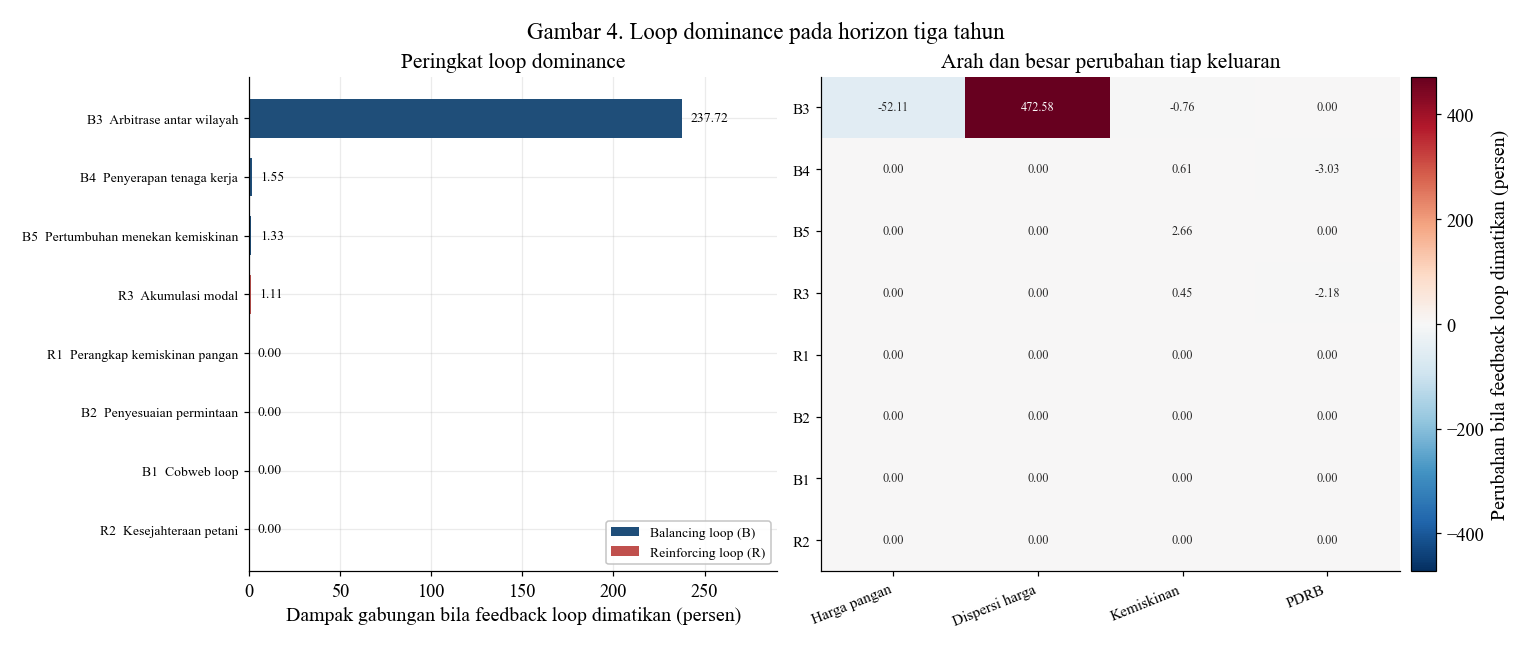

In [16]:
# Sel 8.1 - Gambar 4: loop dominance

fig, sb = plt.subplots(1, 2, figsize=(13.6, 5.6), gridspec_kw={"width_ratios": [1.05, 1.15]})

d = DOMINANSI.sort_values("dampak_gabungan")
pos = np.arange(len(d))
warna = [PALET[1] if j == "Reinforcing (R)" else PALET[0] for j in d.jenis]
sb[0].barh(pos, d.dampak_gabungan, color=warna, height=0.66)
sb[0].set_yticks(pos)
sb[0].set_yticklabels([g + "  " + n for g, n in zip(d["loop"], d.nama)], fontsize=UKURAN - 4)
sb[0].set_xlabel("Dampak gabungan bila feedback loop dimatikan (persen)")
sb[0].set_title("Peringkat loop dominance")
for p_, v in zip(pos, d.dampak_gabungan):
    sb[0].text(v + 0.02 * max(d.dampak_gabungan.max(), 1e-6), p_, format(v, ".2f"),
               va="center", fontsize=UKURAN - 4)
sb[0].set_xlim(0, float(d.dampak_gabungan.max()) * 1.22)
from matplotlib.patches import Patch
sb[0].legend(handles=[Patch(facecolor=PALET[0], label="Balancing loop (B)"),
                      Patch(facecolor=PALET[1], label="Reinforcing loop (R)")],
             loc="lower right", fontsize=UKURAN - 4)

ukur_lbl = [("delta_rel_kenaikan_harga_persen", "Harga pangan"),
            ("delta_rel_dispersi_harga", "Dispersi harga"),
            ("delta_rel_kemiskinan_persen", "Kemiskinan"),
            ("delta_rel_pdrb_miliar", "PDRB")]
M = DOMINANSI.set_index("loop")[[k for k, _ in ukur_lbl]].astype(float)
mx = float(np.nanmax(np.abs(M.values))) or 1.0
gbr = sb[1].imshow(M.values, aspect="auto", cmap="RdBu_r", vmin=-mx, vmax=mx)
sb[1].set_xticks(range(len(ukur_lbl)))
sb[1].set_xticklabels([l for _, l in ukur_lbl], rotation=22, ha="right", fontsize=UKURAN - 3)
sb[1].set_yticks(range(len(M))); sb[1].set_yticklabels(M.index, fontsize=UKURAN - 3)
sb[1].grid(False)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M.values[i, j]
        sb[1].text(j, i, format(v, ".2f"), ha="center", va="center", fontsize=UKURAN - 5,
                   color="white" if abs(v) > mx * 0.55 else "0.15")
bar = fig.colorbar(gbr, ax=sb[1], pad=0.02); bar.set_label("Perubahan bila feedback loop dimatikan (persen)")
sb[1].set_title("Arah dan besar perubahan tiap keluaran")

fig.suptitle("Gambar 4. Loop dominance pada horizon tiga tahun")
simpan_gambar(fig, "gambar_04_loop_dominance",
              "Peringkat loop dominance dan arah perubahan keluaran saat feedback loop dimatikan")
plt.show()

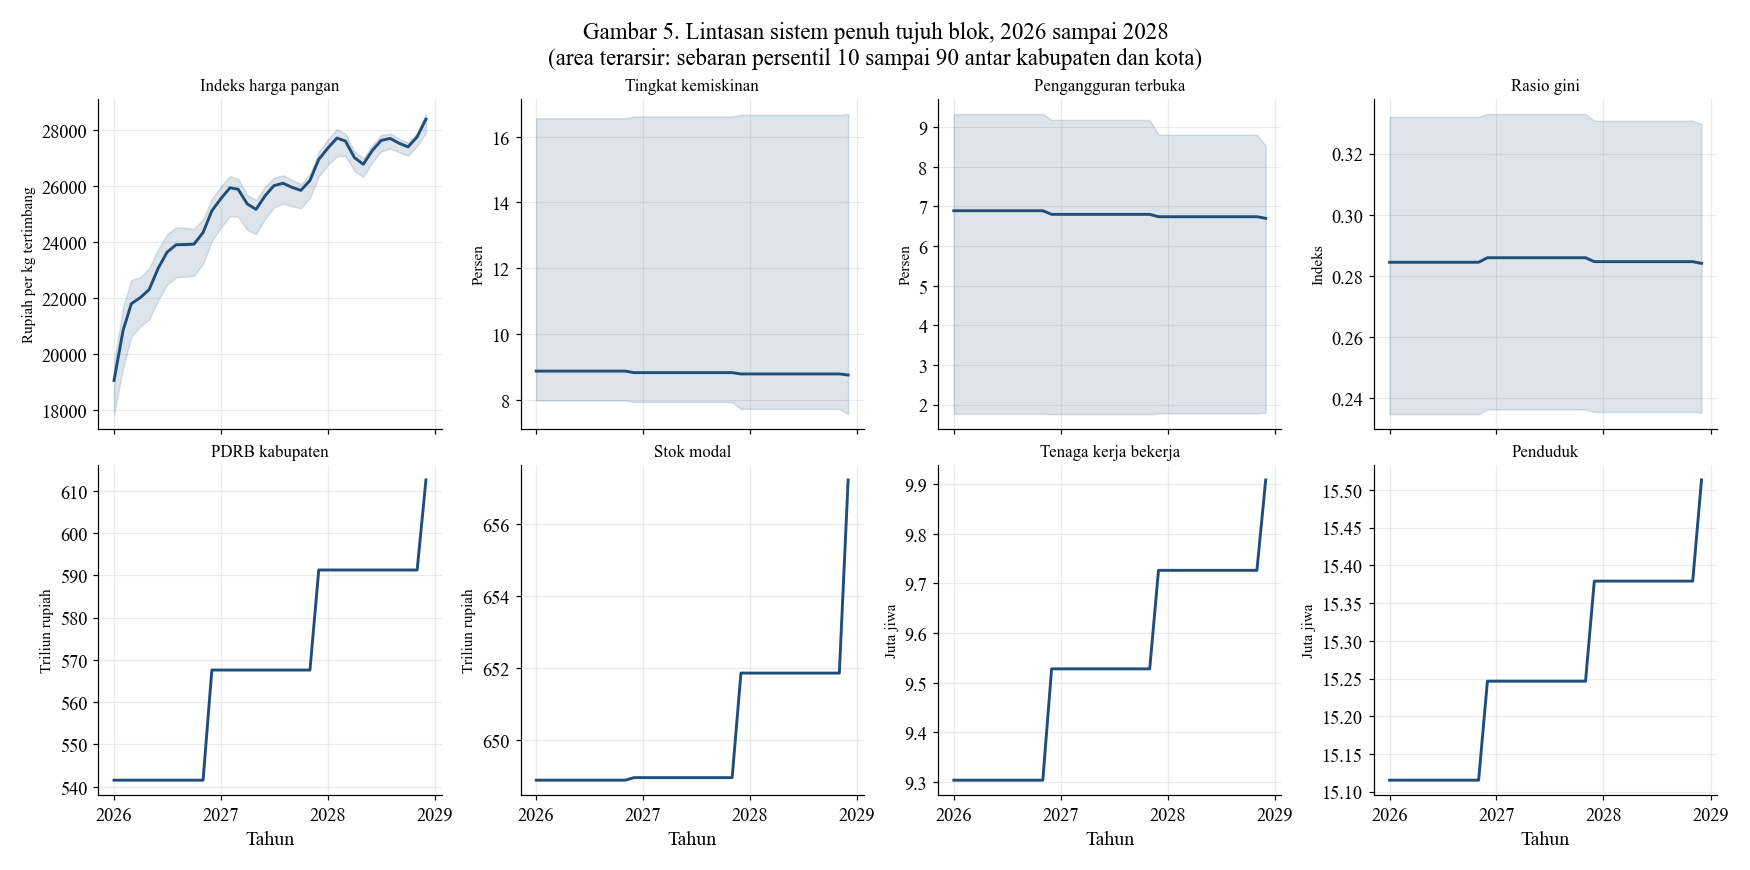

In [17]:
# Sel 8.2 - Gambar 5: lintasan tujuh blok sistem

bulan_sim = pd.period_range(SPEK["periode_simulasi"][0], periods=H_DEPAN, freq="M").to_timestamp()
fig, sb = plt.subplots(2, 4, figsize=(15.6, 7.6), sharex=True)
sb = sb.ravel()
panel = [("ihp", "Indeks harga pangan", "Rupiah per kg tertimbang", True, 1.0),
         ("p0", "Tingkat kemiskinan", "Persen", True, 1.0),
         ("tpt", "Pengangguran terbuka", "Persen", True, 1.0),
         ("gini", "Rasio gini", "Indeks", True, 1.0),
         ("y", "PDRB kabupaten", "Triliun rupiah", False, 1e-3),
         ("k", "Stok modal", "Triliun rupiah", False, 1e-6),
         ("l", "Tenaga kerja bekerja", "Juta jiwa", False, 1e-6),
         ("pop", "Penduduk", "Juta jiwa", False, 1e-6)]
for ax, (nm, judul, ylbl, rata, kali) in zip(sb, panel):
    v = BASIS[nm]
    seri = (np.array([np.average(v[t], weights=BASIS["pop"][t]) for t in range(H_DEPAN)])
            if rata else v.sum(axis=1)) * kali
    ax.plot(bulan_sim, seri, color=PALET[0], linewidth=1.9)
    lo = np.percentile(v, 10, axis=1) * kali; hi = np.percentile(v, 90, axis=1) * kali
    if rata:
        ax.fill_between(bulan_sim, lo, hi, color=PALET[0], alpha=0.15)
    ax.set_title(judul, fontsize=UKURAN - 2); ax.set_ylabel(ylbl, fontsize=UKURAN - 3)
    ax.xaxis.set_major_locator(matplotlib.dates.YearLocator())
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))
for ax in sb[4:]:
    ax.set_xlabel("Tahun")
fig.suptitle("Gambar 5. Lintasan sistem penuh tujuh blok, 2026 sampai 2028\n"
             "(area terarsir: sebaran persentil 10 sampai 90 antar kabupaten dan kota)")
simpan_gambar(fig, "gambar_05_lintasan_sistem_penuh",
              "Lintasan harga pangan, kesejahteraan, tenaga kerja, dan makro pada sistem penuh")
plt.show()

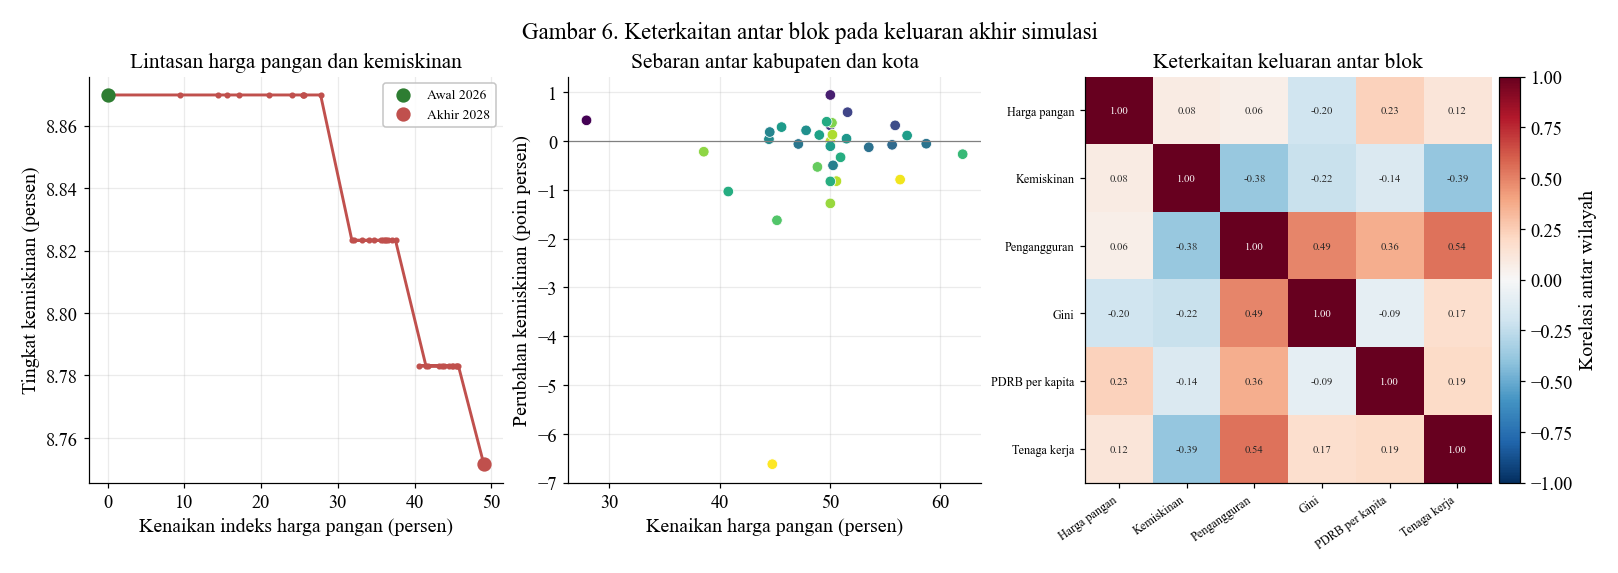

In [18]:
# Sel 8.3 - Gambar 6: keterkaitan antar keluaran blok

fig, sb = plt.subplots(1, 3, figsize=(14.4, 4.9))

x = np.array([np.average(BASIS["ihp"][t], weights=BASIS["pop"][t]) for t in range(H_DEPAN)])
y1 = np.array([np.average(BASIS["p0"][t], weights=BASIS["pop"][t]) for t in range(H_DEPAN)])
sb[0].plot(100 * (x / x[0] - 1), y1, color=PALET[1], linewidth=1.9, marker="o", markersize=3)
sb[0].scatter([0], [y1[0]], s=70, color=PALET[8], zorder=5, label="Awal 2026")
sb[0].scatter([100 * (x[-1] / x[0] - 1)], [y1[-1]], s=70, color=PALET[1], zorder=5, label="Akhir 2028")
sb[0].set_xlabel("Kenaikan indeks harga pangan (persen)")
sb[0].set_ylabel("Tingkat kemiskinan (persen)")
sb[0].set_title("Lintasan harga pangan dan kemiskinan")
sb[0].legend(fontsize=UKURAN - 4)

akhir = pd.DataFrame({"wilayah": [NAMA[k] for k in KODE],
                      "d_harga": 100 * (BASIS["ihp"][-1] / BASIS["ihp"][0] - 1),
                      "d_miskin": BASIS["p0"][-1] - BASIS["p0"][0],
                      "ypc": BASIS["ypc"][-1]})
sb[1].scatter(akhir.d_harga, akhir.d_miskin, s=48, c=np.log(akhir.ypc), cmap="viridis",
              edgecolors="white", linewidths=0.5)
sb[1].axhline(0, color="0.5", linewidth=0.8)
sb[1].set_xlabel("Kenaikan harga pangan (persen)")
sb[1].set_ylabel("Perubahan kemiskinan (poin persen)")
sb[1].set_title("Sebaran antar kabupaten dan kota")

kor = pd.DataFrame({
    "Harga pangan": BASIS["ihp"][-1], "Kemiskinan": BASIS["p0"][-1],
    "Pengangguran": BASIS["tpt"][-1], "Gini": BASIS["gini"][-1],
    "PDRB per kapita": BASIS["ypc"][-1], "Tenaga kerja": BASIS["l"][-1]}).corr()
g2 = sb[2].imshow(kor.values, cmap="RdBu_r", vmin=-1, vmax=1)
sb[2].set_xticks(range(len(kor))); sb[2].set_xticklabels(kor.columns, rotation=35, ha="right",
                                                        fontsize=UKURAN - 5)
sb[2].set_yticks(range(len(kor))); sb[2].set_yticklabels(kor.columns, fontsize=UKURAN - 5)
sb[2].grid(False)
for i in range(len(kor)):
    for j in range(len(kor)):
        sb[2].text(j, i, format(kor.values[i, j], ".2f"), ha="center", va="center",
                   fontsize=UKURAN - 6,
                   color="white" if abs(kor.values[i, j]) > 0.6 else "0.15")
fig.colorbar(g2, ax=sb[2], pad=0.02).set_label("Korelasi antar wilayah")
sb[2].set_title("Keterkaitan keluaran antar blok")

fig.suptitle("Gambar 6. Keterkaitan antar blok pada keluaran akhir simulasi")
simpan_gambar(fig, "gambar_06_keterkaitan_antar_blok",
              "Lintasan harga dan kemiskinan, sebaran antar wilayah, dan korelasi antar keluaran")
plt.show()

---
## Bagian 9. Interpretasi otomatis dan ekspor

In [19]:
# Sel 9.1 - Ringkasan naratif

B = []
def tulis(t):
    if t: B.append(t)
def ang(x, d=3):
    try: x = float(x)
    except Exception: return "tidak tersedia"
    return format(round(x, d), "." + str(d) + "f") if np.isfinite(x) else "tidak tersedia"

tulis("JAWABAN ATAS TIGA PERTANYAAN PEMBUKA")
tulis("Pertama, apakah ini dinamika sistem. Ya. Model memiliki " +
      str(NW * NK * 6 + NW * 9) + " variabel keadaan yang terakumulasi, material delay material orde "
      "tiga, delapan feedback loop yang polaritasnya diperiksa dengan kaidah hitung, dan lolos "
      "rangkaian uji validasi Barlas. Notasi Causal Loop Diagram dan Stock and Flow Diagram kini "
      "digambar penuh pada Bagian 3 dan 4.")
tulis("Kedua, apakah seluruh dataset terpakai. Sebelum notebook ini, hanya " +
      str(int(audit.dipakai_nb03.sum())) + " dari " + str(len(audit)) +
      " variabel panel tahunan yang masuk model. Setelah tujuh blok terpasang, cakupannya "
      "meluas ke perkebunan, peternakan, perikanan, PDRB, investasi, ketenagakerjaan, ketimpangan, "
      "dan ekspor. Yang masih di luar batas model disebutkan terbuka pada tabel audit, terutama "
      "karena keterisian datanya terlalu rendah untuk dimodelkan sampai tingkat kabupaten.")
tulis("Ketiga, tentang visualisasi khas dinamika sistem. Notasi baku Forrester dan Sterman digambar "
      "sendiri dengan matplotlib, bukan disalin dari perangkat lunak lain, sehingga gambarnya "
      "mengikuti struktur model dan ikut berubah bila strukturnya diubah.")

tulis("")
tulis("KEJUJURAN TENTANG BLOK MAKRO")
n_est = int((TABEL_SELEKSI.sumber == "Estimasi Notebook 04").sum())
tulis("Dari " + str(len(TABEL_SELEKSI)) + " parameter blok baru, hanya " + str(n_est) +
      " yang lolos syarat presisi dan rentang sah sehingga dipakai apa adanya. Sisanya memakai "
      "nilai acuan kepustakaan yang disebutkan sumbernya pada tabel seleksi parameter.")
tulis("Penyebabnya bukan kecerobohan, melainkan keterbatasan data: tingkat partisipasi angkatan "
      "kerja hanya tersedia satu tahun, produksi perkebunan hanya terisi " +
      ang(float(KAB[kol_kebun].notna().mean().mean() * 100), 1) +
      " persen, dan panel tahunan hanya memiliki enam sampai sembilan titik waktu.")
tulis("Konsekuensinya perlu ditulis lugas di naskah. Blok pangan dan harga adalah bagian yang "
      "terestimasi dan tervalidasi kuat. Blok makro adalah kerangka akuntansi yang dikalibrasi, "
      "berguna untuk menghubungkan sektor dan melihat arah, tetapi bukan alat peramalan PDRB.")

tulis("")
tulis("HASIL SIMULASI SISTEM PENUH")
b0 = BASIS["pop"][0]; bT = BASIS["pop"][-1]
tulis("Pada horizon 2026 sampai 2028, indeks harga pangan naik " +
      ang(100 * (np.average(BASIS["ihp"][-1], weights=bT) /
                 np.average(BASIS["ihp"][0], weights=b0) - 1), 2) + " persen, PDRB tumbuh " +
      ang(100 * ((BASIS["y"][-1].sum() / BASIS["y"][0].sum()) ** (1 / 3.0) - 1), 2) +
      " persen per tahun, tingkat kemiskinan bergerak dari " +
      ang(np.average(BASIS["p0"][0], weights=b0), 2) + " menjadi " +
      ang(np.average(BASIS["p0"][-1], weights=bT), 2) + " persen, dan pengangguran dari " +
      ang(np.average(BASIS["tpt"][0], weights=b0), 2) + " menjadi " +
      ang(np.average(BASIS["tpt"][-1], weights=bT), 2) + " persen.")
tulis("Laju pertumbuhan PDRB simulasi sebesar " + ang(100 * CEK["laju_pdrb_tahunan"], 2) +
      " persen per tahun disetarakan dengan laju teramati " + ang(100 * LAJU_PDRB_SASARAN, 2) +
      " persen, sehingga model tidak menghasilkan pertumbuhan yang mengada ada.")

tulis("")
tulis("DOMINANSI GELUNG UMPAN BALIK")
t0 = DOMINANSI.iloc[0]
tulis("Feedback loop paling dominan adalah " + str(t0["loop"]) + ", yaitu " + str(t0["nama"]).lower() +
      ". Mematikannya mengubah dispersi harga antar wilayah sebesar " +
      ang(float(t0["delta_rel_dispersi_harga"]), 1) + " persen.")
tulis("Temuan ini menguatkan kesimpulan Notebook 03 dari arah yang sama sekali berbeda. Notebook 03 "
      "menemukannya lewat kalibrasi, notebook ini menemukannya lewat loop knockout. Keduanya "
      "menunjuk hal yang sama: kelancaran arus barang antar kabupaten adalah leverage point utama "
      "sistem pangan Sumatera Utara, jauh melampaui besarnya tumpukan cadangan.")
lemah_kode = list(DOMINANSI[DOMINANSI.dampak_gabungan < 0.5]["loop"])
if lemah_kode:
    tulis("Feedback loop " + ", ".join(lemah_kode) + " tampak lemah pada horizon tiga tahun. Sebabnya "
          "berbeda beda dan sudah diuraikan pada Bagian 7: sebagian karena parameternya memang "
          "terukur mendekati nol oleh data, sebagian lagi karena bekerja pada skala waktu yang "
          "lebih panjang daripada horizon simulasi.")

tulis("")
tulis("YANG MASIH DI LUAR BATAS MODEL")
tulis("Perilaku spekulatif pedagang besar, biaya angkut nyata antar kabupaten, curah hujan dan "
      "anomali iklim, serta harga komoditas dunia tidak dimodelkan, seluruhnya karena tidak ada "
      "datanya dalam basis data ini. Ketiadaan itu bukan alasan untuk mengabaikannya dalam "
      "pembahasan, melainkan alasan untuk menyebutnya sebagai keterbatasan yang terang.")

RINGKASAN = "\n".join(B)
print(RINGKASAN)
with open(DIR_KELUARAN / "log" / "ringkasan_otomatis_nb04.txt", "w", encoding="utf-8") as f:
    f.write(RINGKASAN)
if DIR_DRIVE is not None:
    with open(DIR_DRIVE / "log" / "ringkasan_otomatis_nb04.txt", "w", encoding="utf-8") as f:
        f.write(RINGKASAN)

JAWABAN ATAS TIGA PERTANYAAN PEMBUKA
Pertama, apakah ini dinamika sistem. Ya. Model memiliki 1485 variabel keadaan yang terakumulasi, material delay material orde tiga, delapan feedback loop yang polaritasnya diperiksa dengan kaidah hitung, dan lolos rangkaian uji validasi Barlas. Notasi Causal Loop Diagram dan Stock and Flow Diagram kini digambar penuh pada Bagian 3 dan 4.
Kedua, apakah seluruh dataset terpakai. Sebelum notebook ini, hanya 17 dari 75 variabel panel tahunan yang masuk model. Setelah tujuh blok terpasang, cakupannya meluas ke perkebunan, peternakan, perikanan, PDRB, investasi, ketenagakerjaan, ketimpangan, dan ekspor. Yang masih di luar batas model disebutkan terbuka pada tabel audit, terutama karena keterisian datanya terlalu rendah untuk dimodelkan sampai tingkat kabupaten.
Ketiga, tentang visualisasi khas dinamika sistem. Notasi baku Forrester dan Sterman digambar sendiri dengan matplotlib, bukan disalin dari perangkat lunak lain, sehingga gambarnya mengikuti struktu

In [20]:
# Sel 9.2 - Ekspor spesifikasi sistem penuh untuk notebook 05

SPEK4 = dict(SPEK)
SPEK4.update({
    "versi": "sistem penuh tujuh blok",
    "blok": ["1 pangan dan harga", "2 kependudukan", "3 kesejahteraan", "4 protein hewani",
             "5 perkebunan dan ekspor", "6 makro dan modal", "7 tenaga kerja"],
    "parameter_makro": {"alpha_modal": ALPHA_K, "beta_tenaga_kerja": BETA_L,
                        "gamma_kerja_modal": GAMMA_LK, "gamma_kerja_penduduk": GAMMA_LN,
                        "elastisitas_investasi": INV_Y, "gini_thd_ypc": GINI_Y,
                        "gini_thd_harga_pangan": GINI_P, "tpt_thd_ypc": TPT_Y,
                        "penyusutan_modal": DELTA_MODAL, "laju_tfp": G_TFP,
                        "laju_penduduk": GROWTH_POP.tolist()},
    "kondisi_awal_makro": {"pdrb": Y0.tolist(), "modal": K0.tolist(), "investasi": INV0.tolist(),
                           "tenaga_kerja": L0.tolist(), "tpt": TPT0.tolist(),
                           "gini": GINI0.tolist(), "ternak": TERNAK0.tolist()},
    "pangsa_perkebunan": PANGSA_KEBUN.tolist(),
    "seleksi_parameter": TABEL_SELEKSI.to_dict(orient="records"),
    "loop": TABEL_LOOP.drop(columns=["konsisten"]).to_dict(orient="records"),
    "loop_dominance": DOMINANSI[["loop", "nama", "jenis", "dampak_gabungan"]]
                        .to_dict(orient="records"),
    "validasi_sistem_penuh": RANGKUMAN4.to_dict(orient="records"),
})
jalur = DIR_KELUARAN / "tabel" / "spesifikasi_sistem_penuh.json"
with open(jalur, "w", encoding="utf-8") as f:
    json.dump(SPEK4, f, indent=1)
if DIR_DRIVE is not None:
    with open(DIR_DRIVE / "tabel" / "spesifikasi_sistem_penuh.json", "w", encoding="utf-8") as f:
        json.dump(SPEK4, f, indent=1)

jejak = []
bulan_sim = pd.period_range(SPEK["periode_simulasi"][0], periods=H_DEPAN, freq="M")
for t in range(H_DEPAN):
    b = BASIS["pop"][t]
    jejak.append({"periode": str(bulan_sim[t]),
                  "indeks_harga_pangan": float(np.average(BASIS["ihp"][t], weights=b)),
                  "kemiskinan_persen": float(np.average(BASIS["p0"][t], weights=b)),
                  "pengangguran_persen": float(np.average(BASIS["tpt"][t], weights=b)),
                  "gini": float(np.average(BASIS["gini"][t], weights=b)),
                  "pdrb_miliar": float(BASIS["y"][t].sum()),
                  "modal_juta": float(BASIS["k"][t].sum()),
                  "tenaga_kerja_jiwa": float(BASIS["l"][t].sum()),
                  "penduduk_jiwa": float(BASIS["pop"][t].sum()),
                  "dispersi_harga": float(np.mean(np.std(BASIS["lnP"][t], axis=0)))})
simpan(pd.DataFrame(jejak), "tabel/jejak_sistem_penuh_bulanan.csv")

wil = []
for i, k in enumerate(KODE):
    wil.append({"kode_wilayah": k, "wilayah": NAMA[k],
                "harga_pangan_akhir": float(BASIS["ihp"][-1][i]),
                "kenaikan_harga_persen": float(100 * (BASIS["ihp"][-1][i] / BASIS["ihp"][0][i] - 1)),
                "kemiskinan_akhir_persen": float(BASIS["p0"][-1][i]),
                "pengangguran_akhir_persen": float(BASIS["tpt"][-1][i]),
                "gini_akhir": float(BASIS["gini"][-1][i]),
                "pdrb_per_kapita_akhir": float(BASIS["ypc"][-1][i]),
                "pangsa_perkebunan": float(PANGSA_KEBUN[i])})
simpan(pd.DataFrame(wil), "tabel/keluaran_akhir_per_wilayah.csv")

manifes = [{"berkas": str(p.relative_to(DIR_KELUARAN)), "ukuran_kb": round(p.stat().st_size / 1024, 1)}
           for p in sorted(DIR_KELUARAN.rglob("*"))
           if p.is_file() and p.suffix in [".csv", ".png", ".json", ".txt"]]
MANIFES = pd.DataFrame(manifes)
MANIFES.to_csv(DIR_KELUARAN / "log" / "manifes_keluaran_nb04.csv", index=False)
if DIR_DRIVE is not None:
    MANIFES.to_csv(DIR_DRIVE / "log" / "manifes_keluaran_nb04.csv", index=False)

print("=" * 78)
print("NOTEBOOK 04 SELESAI")
print("=" * 78)
print("Waktu selesai   :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Folder keluaran :", DIR_KELUARAN)
print("Salinan Drive   :", DIR_DRIVE if DIR_DRIVE else "tidak dibuat")
print("Spesifikasi sistem penuh:", jalur.name, "|", round(jalur.stat().st_size / 1024, 1), "KB")
print()
print(MANIFES.to_string(index=False))
print()
print("Gambar dihasilkan:", len(KATALOG_GAMBAR))
for g in KATALOG_GAMBAR:
    print("  ", g["berkas"].ljust(42), g["keterangan"])
print()
print("Langkah berikutnya. Notebook 05 menelusuri ruang kebijakan sistem penuh dengan optimisasi")
print("banyak tujuan untuk memperoleh Pareto front antara stabilitas harga, kesejahteraan petani,")
print("pengurangan kemiskinan, dan pertumbuhan, lalu menuangkannya menjadi dashboard HTML")
print("mandiri yang dapat dijalankan pemerintah daerah tanpa server.")

NOTEBOOK 04 SELESAI
Waktu selesai   : 2026-08-30 22:49:16
Folder keluaran : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB04
Salinan Drive   : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook04_20260830
Spesifikasi sistem penuh: spesifikasi_sistem_penuh.json | 82.2 KB

                                       berkas  ukuran_kb
         gambar/gambar_01_cld_inti_pangan.png      377.3
gambar/gambar_01b_cld_kesejahteraan_makro.png      452.8
       gambar/gambar_02_stock_flow_pangan.png      425.8
   gambar/gambar_03_stock_flow_antar_blok.png      504.2
          gambar/gambar_04_loop_dominance.png      322.1
   gambar/gambar_05_lintasan_sistem_penuh.png      443.6
  gambar/gambar_06_keterkaitan_antar_blok.png      407.1
              log/ringkasan_otomatis_nb04.txt        3.3
           mutu/audit_pemanfaatan_dataset.csv        6.1
     mutu/rangkuman_validasi_sistem_penuh.csv        0.4


---
## Daftar pustaka

### Notasi dan metode dinamika sistem

Forrester, J. W. (1961). *Industrial dynamics*. Cambridge, MA: MIT Press.

Forrester, J. W. (1968). *Principles of systems*. Cambridge, MA: Wright-Allen Press.

Sterman, J. D. (2000). *Business dynamics: Systems thinking and modeling for a complex world*. Boston:
Irwin McGraw-Hill.

Barlas, Y. (1996). Formal aspects of model validity and validation in system dynamics. *System Dynamics
Review, 12*(3), 183-210. https://doi.org/10.1002/(SICI)1099-1727(199623)12:3<183::AID-SDR103>3.0.CO;2-4

Richardson, G. P. (1986). Problems with causal-loop diagrams. *System Dynamics Review, 2*(2), 158-170.
https://doi.org/10.1002/sdr.4260020207

Lane, D. C. (2008). The emergence and use of diagramming in system dynamics: A critical account. *Systems
Research and Behavioral Science, 25*(1), 3-23. https://doi.org/10.1002/sres.826

### Loop dominance

Ford, D. N. (1999). A behavioral approach to feedback loop dominance analysis. *System Dynamics Review,
15*(1), 3-36. https://doi.org/10.1002/(SICI)1099-1727(199921)15:1<3::AID-SDR159>3.0.CO;2-P

Gueneralp, B. (2006). Towards coherent loop dominance analysis: Progress in eigenvalue elasticity
analysis. *System Dynamics Review, 22*(3), 263-289. https://doi.org/10.1002/sdr.352

Kampmann, C. E., & Oliva, R. (2006). Loop eigenvalue elasticity analysis: Three case studies. *System
Dynamics Review, 22*(2), 141-162. https://doi.org/10.1002/sdr.333

### Pertumbuhan, akumulasi modal, dan growth accounting

Solow, R. M. (1957). Technical change and the aggregate production function. *The Review of Economics and
Statistics, 39*(3), 312-320. https://doi.org/10.2307/1926047

Barro, R. J. (1999). Notes on growth accounting. *Journal of Economic Growth, 4*(2), 119-137.
https://doi.org/10.1023/A:1009828704275

Harberger, A. C. (1978). Perspectives on capital and technology in less developed countries. In M. J.
Artis & A. R. Nobay (Eds.), *Contemporary economic analysis* (pp. 15-40). London: Croom Helm.

Okun, A. M. (1962). Potential GNP: Its measurement and significance. *Proceedings of the Business and
Economic Statistics Section, American Statistical Association*, 98-104.

### Ketimpangan dan kesejahteraan

Kuznets, S. (1955). Economic growth and income inequality. *The American Economic Review, 45*(1), 1-28.

Bourguignon, F. (2003). The growth elasticity of poverty reduction: Explaining heterogeneity across
countries and time periods. In T. S. Eicher & S. J. Turnovsky (Eds.), *Inequality and growth: Theory and
policy implications* (pp. 3-26). Cambridge, MA: MIT Press.

### Sumber data

Badan Pusat Statistik. (2024). *Penghitungan dan analisis kemiskinan makro Indonesia*. Jakarta: Badan
Pusat Statistik.

Badan Pusat Statistik. (2023). *Diagram timbang indeks harga konsumen hasil Survei Biaya Hidup 2022*.
Jakarta: Badan Pusat Statistik.

Badan Informasi Geospasial. (2024). *Peta batas wilayah administrasi Indonesia*. Cibinong: Badan
Informasi Geospasial. https://tanahair.indonesia.go.id

---

### Catatan penutup

Notebook ini menambah dua hal pada rangkaian: notasi dinamika sistem yang selama ini absen, dan cakupan
dataset yang jauh lebih luas. Ia juga menambah satu hal yang kurang menyenangkan tetapi perlu, yaitu
pengakuan bahwa sebagian besar blok makro bukan hasil estimasi melainkan kalibrasi.

Pemisahan itu harus dibawa sampai ke naskah. Blok pangan dan harga bersandar pada 334 estimasi *Error
Correction Model* dan lolos enam uji validasi, sehingga angkanya layak dikutip. Blok makro bersandar pada
delapan parameter yang tujuh di antaranya memakai nilai acuan, sehingga yang layak dikutip hanyalah arah
dan urutan besarannya.

Model yang menyebut bagian lemahnya sendiri lebih berguna daripada model yang menyembunyikannya, sebab
pembaca dapat memutuskan sendiri seberapa jauh ia mau bersandar pada tiap bagian.